In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import ast
import radon
import networkx as nx
from textwrap import wrap

In [ ]:

import pandas as pd
from pathlib import Path


INPUT_CSV = Path("thinned_snapshots.csv")
OUTPUT_FOLDER = Path("./UserStudy_Snapshots/json")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

TIME_FORMAT = "%Y-%m-%d %H:%M:%S.%f"
SNAPSHOT_INTERVAL_SECONDS = 60

FILE_PLACEHOLDER = "SUBMISSION"

# time format function
def safe_format_time(value):
    try:
        ts = pd.to_datetime(value)
        return ts.strftime(TIME_FORMAT)[:-3]  
    except Exception:
        return str(value)

print(f"Processing: {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)


df = df.rename(columns={
    "user_id": "StudentID",
    "exercise_id": "AssignmentID",
    "code_snapshot": "CodeSnapshot",
    "snapshot_sequence_num": "SessionID"
})

df["File"] = FILE_PLACEHOLDER

df["StartTime"] = pd.to_datetime(df["snapshot_time"])
df["EndTime"] = df["StartTime"] + pd.to_timedelta(
    SNAPSHOT_INTERVAL_SECONDS, unit="s"
)

df["StartTime"] = df["StartTime"].apply(safe_format_time)
df["EndTime"] = df["EndTime"].apply(safe_format_time)

#output
df_out = df[
    [
        "StudentID",
        "AssignmentID",
        "File",
        "StartTime",
        "EndTime",
        "CodeSnapshot"
    ]
]

output_json = OUTPUT_FOLDER / f"{INPUT_CSV.stem}.json"

df_out.to_json(
    output_json,
    orient="records",
    indent=2
)

print(f"→ written: {output_json}")
print("Conversion completed.")


Processing: thinned_snapshots.csv
→ written: UserStudy_Snapshots/json/thinned_snapshots.json
Conversion completed.


/var/folders/m7/_19c6qdn7x94dpg6n14c0jv00000gn/T/ipykernel_40944/1040764425.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["StartTime"] = pd.to_datetime(df["snapshot_time"])


### Llama

In [ ]:
import os
import json
import re
import time
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from groq import Groq

load_dotenv()
GROQ_KEY = os.getenv("GROQ_API_KEY")
if GROQ_KEY is None:
    raise ValueError("GROQ_API_KEY not set in environment or .env file")

# Settings
DRY_RUN = False
GROQ_MODEL = "llama-3.3-70b-versatile"

input_folder = "./UserStudy_Snapshots_JSON/"   
output_folder = "./Student_snapshots_CT_analysis_Llama/"
os.makedirs(output_folder, exist_ok=True)

TARGETS_CSV = "snapshots_count.csv"
ASSIGNMENT_INFO_CSV = "assignment_info.csv"

MIN_SNAPSHOTS = 1

client = Groq(api_key=GROQ_KEY)

# CT facet definitions
ct_facet_definitions = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency level definitions
proficiency_level_definitions = {
    "1": "Not Proficient – The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    "2": "Emerging – The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    "3": "Developing – The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    "4": "Proficient – The student shows a solid understanding and effective use of this facet in most contexts.",
    "5": "Highly Proficient – The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

# JSON parsing helpers 
def extract_json_array_str(text: str):
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None


def safe_parse_ct_analysis(llm_output_text: str):
    arr_str = extract_json_array_str(llm_output_text)
    if not arr_str:
        return []

    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return []


# LLM prompt
def create_process_prompt(student_id, process_data, exercise_description, exercise_requirements, sample_output):
    prompt = f"""
You are a computer science education researcher analyzing a student's programming process data.
Analyze the student's computational thinking (CT) based on sequential code snapshots.

Student ID: {student_id}
Exercise/Assignment ID: {process_data.get("AssignmentID")}

### Exercise Description
{exercise_description}

### Exercise Requirements
{exercise_requirements}

### Sample Output
{sample_output}

Snapshot Interval: {process_data.get('snapshot_interval', 'Unknown')}

### CT Facets
{json.dumps(ct_facet_definitions, indent=2)}

### Proficiency Level Definitions
{json.dumps(proficiency_level_definitions, indent=2)}

### Process Summary
- Duration (seconds): {process_data.get('duration_seconds', 0)}
- Number of snapshots: {process_data.get('total_snapshots', 0)}
- Average code length: {process_data.get('avg_code_length', 0)}
- Number of code changes: {process_data.get('num_code_changes', 0)}
- Average typing rate (chars/sec): {process_data.get('avg_typing_rate_chars_per_sec', 0)}

### Code Snapshots
"""
    for s in process_data.get("snapshots", []):
        code_content = s.get("CodeSnapshot") or s.get("CodeSnapshots") or s.get("code") or ""
        code_content = code_content.replace("\\n", "\n")
        prompt += f"\nSnapshot {s.get('StartTime', 'Unknown')}:\n{code_content}\n"

    prompt += """
### Task
Analyze how the student's computational thinking (CT) evolved throughout the process.
For each CT facet, assess the student's demonstrated proficiency based on their code evolution, structure, and refinement.

Return **ONLY JSON** in this format:
[
  {
    "facet": "<CT facet name>",
    "proficiency_level": <1-5>,
    "evidence": "<Detailed explanation regarding the proficiency_level that you assigned>"
  }
]
"""
    return prompt.strip()

# Analyze one (student, assignment) within one JSON file
def analyze_target_in_file(filepath, student_id, assignment_id,
                           exercise_description, exercise_requirements, sample_output):

    with open(filepath, "r", encoding="utf-8") as f:
        all_snapshots = json.load(f)

    snapshots = [
        s for s in all_snapshots
        if s.get("StudentID") == student_id
        and s.get("AssignmentID") == assignment_id
    ]

    if not snapshots:
        return None

    # metrics
    start_ts = np.datetime64(snapshots[0]["StartTime"])
    end_ts = np.datetime64(snapshots[-1]["EndTime"])
    duration = (end_ts - start_ts) / np.timedelta64(1, "s")

    code_lengths = [len((s.get("CodeSnapshot") or "")) for s in snapshots]
    avg_chars = float(np.mean(code_lengths)) if code_lengths else 0.0
    total_changes = int(sum(abs(code_lengths[i] - code_lengths[i - 1]) for i in range(1, len(code_lengths))))
    avg_typing_rate = (total_changes / float(duration)) if float(duration) > 0 else 0.0

    process_data = {
        "StudentID": student_id,
        "AssignmentID": assignment_id,
        "source_json": os.path.basename(filepath),
        "duration_seconds": float(duration),
        "total_snapshots": int(len(snapshots)),
        "avg_code_length": int(avg_chars),
        "num_code_changes": int(total_changes),
        "avg_typing_rate_chars_per_sec": round(float(avg_typing_rate), 2),
        "snapshot_interval": "60 seconds",
        "snapshots": snapshots
    }

    prompt = create_process_prompt(
        student_id,
        process_data,
        exercise_description=exercise_description,
        exercise_requirements=exercise_requirements,
        sample_output=sample_output
    )

    if DRY_RUN:
        process_data["CT_analysis"] = [{
            "facet": "DryRun",
            "proficiency_level": 0,
            "evidence": "Dry run: prompt generated, no LLM call."
        }]
        return process_data

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": "You are an expert in evaluating computational thinking (CT) in student code. Return ONLY valid JSON."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    llm_output_text = response.choices[0].message.content
    process_data["raw_llm_output"] = llm_output_text
    process_data["CT_analysis"] = safe_parse_ct_analysis(llm_output_text)

    if not process_data["CT_analysis"]:
        retry_prompt = prompt + "\n\nREMINDER: Output MUST be valid JSON array ONLY. No extra text."
        response2 = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": "Return ONLY valid JSON array. No markdown. No extra text."},
                {"role": "user", "content": retry_prompt}
            ],
            temperature=0
        )
        llm_output_text2 = response2.choices[0].message.content
        process_data["raw_llm_output_retry"] = llm_output_text2
        process_data["CT_analysis"] = safe_parse_ct_analysis(llm_output_text2)

    return process_data


targets_df = pd.read_csv(TARGETS_CSV)
targets_df.columns = [c.strip() for c in targets_df.columns]

info_df = pd.read_csv(ASSIGNMENT_INFO_CSV)
info_df.columns = [c.strip() for c in info_df.columns]

colmap = {}

if "SubjectID" not in targets_df.columns:
    if "user_id" in targets_df.columns:
        colmap["user_id"] = "SubjectID"
    elif "StudentID" in targets_df.columns:
        colmap["StudentID"] = "SubjectID"

if "AssignmentID" not in targets_df.columns:
    if "exercise_id" in targets_df.columns:
        colmap["exercise_id"] = "AssignmentID"
    elif "Assignment" in targets_df.columns:
        colmap["Assignment"] = "AssignmentID"

if "Snapshots Count" not in targets_df.columns:
    if "thinned_snapshots_count" in targets_df.columns:
        colmap["thinned_snapshots_count"] = "Snapshots Count"
    else:
        for alt in ["SnapshotsCount", "snapshot_count", "count", "n_snapshots", "Snapshots", "NumSnapshots"]:
            if alt in targets_df.columns:
                colmap[alt] = "Snapshots Count"
                break

if colmap:
    targets_df = targets_df.rename(columns=colmap)

targets_required = {"SubjectID", "AssignmentID", "Snapshots Count"}
missing_targets = targets_required - set(targets_df.columns)
if missing_targets:
    raise ValueError(f"Targets CSV missing columns: {missing_targets}")

info_colmap = {}
if "AssignmentID" not in info_df.columns:
    if "exercise_id" in info_df.columns:
        info_colmap["exercise_id"] = "AssignmentID"
    elif "Assignment" in info_df.columns:
        info_colmap["Assignment"] = "AssignmentID"

if info_colmap:
    info_df = info_df.rename(columns=info_colmap)

info_required = {"AssignmentID", "exercise_description", "exercise_requirements", "sample_output"}
missing_info = info_required - set(info_df.columns)
if missing_info:
    raise ValueError(f"Assignment info CSV missing columns: {missing_info}")

targets_df = targets_df[targets_df["Snapshots Count"] >= MIN_SNAPSHOTS].copy()

merged = targets_df.merge(
    info_df,
    on=["AssignmentID"],
    how="left"
)

missing_info_rows = (
    merged["exercise_description"].isna()
    | merged["exercise_requirements"].isna()
    | merged["sample_output"].isna()
)
if missing_info_rows.any():
    bad = merged.loc[missing_info_rows, ["SubjectID", "AssignmentID"]].head(20)
    print("WARNING: Some targets have no matching assignment_info (showing up to 20):")
    print(bad.to_string(index=False))

print(f"Loaded {len(merged)} targets after merge.")

for _, row in merged.iterrows():
    student_id = row["SubjectID"]
    assignment_id = row["AssignmentID"]

    exercise_description = "" if pd.isna(row["exercise_description"]) else str(row["exercise_description"])
    exercise_requirements = "" if pd.isna(row["exercise_requirements"]) else str(row["exercise_requirements"])
    sample_output = "" if pd.isna(row["sample_output"]) else str(row["sample_output"])

    found_any = False

    for filename in os.listdir(input_folder):
        if not filename.endswith(".json"):
            continue

        filepath = os.path.join(input_folder, filename)
        result = analyze_target_in_file(
            filepath,
            student_id,
            assignment_id,
            exercise_description,
            exercise_requirements,
            sample_output
        )

        if result is not None:
            found_any = True

            out_name = f"{student_id}_{assignment_id}_CT_analysis.json"
            out_path = os.path.join(output_folder, out_name)

            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, indent=2, ensure_ascii=False)

            print(f"Saved: {out_path}")
            time.sleep(1)
            break  

    if not found_any:
        print(f"No snapshots found for {student_id}/{assignment_id} in any JSON file.")


Loaded 171 targets after merge.
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_434_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_568_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_547_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_2171_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_1949_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_1_2135_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_2_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_2_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_2_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Llama/Student_

In [ ]:
# Get CT Levels - Llama

import os
import json
import pandas as pd

INPUT_FOLDER = "./Student_snapshots_CT_analysis_Llama"  
OUTPUT_CSV = "CT_levels_Llama.csv"

FACETS = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

rows = []

for fn in os.listdir(INPUT_FOLDER):
    if not fn.endswith(".json"):
        continue

    path = os.path.join(INPUT_FOLDER, fn)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    student = data.get("StudentID") or data.get("SubjectID")
    assignment = data.get("AssignmentID")
    codestate = data.get("File") or data.get("CodeStateSection")

    row = {
        "SubjectID": student,
        "AssignmentID": assignment,
        "CodeStateSection": codestate,
    }

    for facet in FACETS:
        row[facet] = pd.NA

    for item in data.get("CT_analysis", []) or []:
        facet = item.get("facet")
        level = item.get("proficiency_level")
        if facet in row:
            row[facet] = level

    rows.append(row)

df = pd.DataFrame(rows)

for facet in FACETS:
    df[facet] = pd.to_numeric(df[facet], errors="coerce").astype("Int64")

df["StudentNum"] = df["SubjectID"].astype(str).str.extract(r"(\d+)").astype(float)
df["AssignNum"] = df["AssignmentID"].astype(str).str.extract(r"(\d+)").astype(float)
df = df.sort_values(["StudentNum", "AssignNum", "CodeStateSection"]).drop(columns=["StudentNum", "AssignNum"])

df.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote: {OUTPUT_CSV}")


Wrote: CT_levels.csv


### Gemini

In [ ]:
import os
import json
import re
import time
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import google.generativeai as genai


load_dotenv()
GEMINI_KEY = os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")
if GEMINI_KEY is None:
    raise ValueError("GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment or .env file")

genai.configure(api_key=GEMINI_KEY)

# Settings
DRY_RUN = False
GEMINI_MODEL_NAME = "gemini-2.5-flash"

input_folder = "./UserStudy_Snapshots_JSON/"
output_folder = "./Student_snapshots_CT_analysis_Gemini/"
os.makedirs(output_folder, exist_ok=True)

TARGETS_CSV = "snapshots_count.csv"
ASSIGNMENT_INFO_CSV = "assignment_info.csv"

MIN_SNAPSHOTS = 1

REQUEST_TIMEOUT_SECONDS = 240
MAX_SNAPSHOTS = 33
MAX_CHARS_PER_SNAPSHOT = 1251

model = genai.GenerativeModel(GEMINI_MODEL_NAME)

# CT facet definitions
ct_facet_definitions = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency level definitions
proficiency_level_definitions = {
    "1": "Not Proficient – The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    "2": "Emerging – The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    "3": "Developing – The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    "4": "Proficient – The student shows a solid understanding and effective use of this facet in most contexts.",
    "5": "Highly Proficient – The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

# JSON extraction helpers
def extract_json_array_str(text: str):
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None


def safe_parse_ct_analysis(model_text: str):
    arr_str = extract_json_array_str(model_text)
    if not arr_str:
        return []
    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return []

# ------------------------------
# Snapshot shrinking
# ------------------------------
def truncate_code(code: str, max_chars: int) -> str:
    code = code or ""
    if len(code) <= max_chars:
        return code
    head = code[: max_chars // 2]
    tail = code[-max_chars // 2 :]
    return head + "\n\n# ... (truncated) ...\n\n" + tail


def pick_evenly_spaced(items, k):
    """Return up to k items, evenly spaced from the list."""
    n = len(items)
    if n <= k:
        return items
    idxs = np.linspace(0, n - 1, num=k, dtype=int)
    return [items[i] for i in idxs]

# LLM Prompt 
def create_process_prompt(student_id, process_data, exercise_description, exercise_requirements, sample_output):
    prompt = f"""
You are a CS education researcher analyzing a student's programming process.

Student ID: {student_id}
Exercise/Assignment ID: {process_data.get("AssignmentID")}

Exercise Description:
{exercise_description}

Exercise Requirements:
{exercise_requirements}

Sample Output:
{sample_output}

CT Facets:
{json.dumps(ct_facet_definitions, indent=2)}

Proficiency Levels (1-5):
{json.dumps(proficiency_level_definitions, indent=2)}

Process Summary:
- Duration (seconds): {process_data.get('duration_seconds', 0)}
- Number of snapshots: {process_data.get('total_snapshots', 0)}
- Average code length: {process_data.get('avg_code_length', 0)}
- Number of code changes: {process_data.get('num_code_changes', 0)}
- Average typing rate (chars/sec): {process_data.get('avg_typing_rate_chars_per_sec', 0)}

Code Snapshots (subset):
"""
    for s in process_data.get("snapshots", []):
        code_content = s.get("CodeSnapshot") or ""
        code_content = code_content.replace("\\n", "\n")
        prompt += f"\nSnapshot {s.get('StartTime', 'Unknown')}:\n{code_content}\n"

    prompt += """
### Task
Analyze how the student's computational thinking (CT) evolved throughout the process.
For each CT facet, assess the student's demonstrated proficiency based on their code evolution, structure, and refinement.

Return **ONLY JSON** in this format:
[
  {
    "facet": "<CT facet name>",
    "proficiency_level": <1-5>,
    "evidence": "<Detailed explanation regarding the proficiency_level that you assigned>"
  }
]
"""
    return prompt.strip()

# Gemini call with timeout
def call_gemini(prompt: str) -> str:
    resp = model.generate_content(
        prompt,
        generation_config=genai.types.GenerationConfig(temperature=0.0),
        request_options={"timeout": REQUEST_TIMEOUT_SECONDS},
    )
    return (resp.text or "").strip()

# Analyze one target inside one JSON file
def analyze_target_in_file(filepath, student_id, assignment_id,
                           exercise_description, exercise_requirements, sample_output):

    with open(filepath, "r", encoding="utf-8") as f:
        all_snapshots = json.load(f)

    snapshots = [
        s for s in all_snapshots
        if s.get("StudentID") == student_id
        and s.get("AssignmentID") == assignment_id
    ]

    if not snapshots:
        return None


    try:
        snapshots = sorted(snapshots, key=lambda x: x.get("StartTime", ""))
    except Exception:
        pass

    sampled = pick_evenly_spaced(snapshots, MAX_SNAPSHOTS)
    for s in sampled:
        s["CodeSnapshot"] = truncate_code(s.get("CodeSnapshot") or "", MAX_CHARS_PER_SNAPSHOT)

    # metrics
    start_ts = np.datetime64(snapshots[0]["StartTime"])
    end_ts = np.datetime64(snapshots[-1]["EndTime"])
    duration = (end_ts - start_ts) / np.timedelta64(1, "s")

    code_lengths_full = [len((s.get("CodeSnapshot") or "")) for s in snapshots]
    avg_chars = float(np.mean(code_lengths_full)) if code_lengths_full else 0.0
    total_changes = int(sum(abs(code_lengths_full[i] - code_lengths_full[i - 1]) for i in range(1, len(code_lengths_full))))
    avg_typing_rate = (total_changes / float(duration)) if float(duration) > 0 else 0.0

    process_data = {
        "StudentID": student_id,
        "AssignmentID": assignment_id,
        "source_json": os.path.basename(filepath),
        "duration_seconds": float(duration),
        "total_snapshots": int(len(snapshots)),
        "avg_code_length": int(avg_chars),
        "num_code_changes": int(total_changes),
        "avg_typing_rate_chars_per_sec": round(float(avg_typing_rate), 2),
        "snapshot_interval": "60 seconds",
        "snapshots": sampled,  
    }

    prompt = create_process_prompt(
        student_id,
        process_data,
        exercise_description,
        exercise_requirements,
        sample_output
    )

    if DRY_RUN:
        process_data["CT_analysis"] = [{
            "facet": "DryRun",
            "proficiency_level": 0,
            "evidence": "Dry run: prompt generated, no LLM call."
        }]
        return process_data

    llm_text = call_gemini(prompt)
    process_data["raw_llm_output"] = llm_text
    process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text)

    if not process_data["CT_analysis"]:
        retry_prompt = prompt + "\n\nIMPORTANT: Output must be ONLY a JSON array."
        llm_text2 = call_gemini(retry_prompt)
        process_data["raw_llm_output_retry"] = llm_text2
        process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text2)

    return process_data

targets_df = pd.read_csv(TARGETS_CSV)
targets_df.columns = [c.strip() for c in targets_df.columns]

info_df = pd.read_csv(ASSIGNMENT_INFO_CSV)
info_df.columns = [c.strip() for c in info_df.columns]

colmap = {}
if "SubjectID" not in targets_df.columns:
    if "user_id" in targets_df.columns:
        colmap["user_id"] = "SubjectID"
    elif "StudentID" in targets_df.columns:
        colmap["StudentID"] = "SubjectID"

if "AssignmentID" not in targets_df.columns:
    if "exercise_id" in targets_df.columns:
        colmap["exercise_id"] = "AssignmentID"

if "Snapshots Count" not in targets_df.columns:
    if "thinned_snapshots_count" in targets_df.columns:
        colmap["thinned_snapshots_count"] = "Snapshots Count"

if colmap:
    targets_df = targets_df.rename(columns=colmap)

targets_required = {"SubjectID", "AssignmentID", "Snapshots Count"}
missing_targets = targets_required - set(targets_df.columns)
if missing_targets:
    raise ValueError(f"Targets CSV missing columns AFTER normalization: {missing_targets}")

info_colmap = {}
if "AssignmentID" not in info_df.columns:
    if "exercise_id" in info_df.columns:
        info_colmap["exercise_id"] = "AssignmentID"
if info_colmap:
    info_df = info_df.rename(columns=info_colmap)

info_required = {"AssignmentID", "exercise_description", "exercise_requirements", "sample_output"}
missing_info = info_required - set(info_df.columns)
if missing_info:
    raise ValueError(f"Assignment info CSV missing columns: {missing_info}")

targets_df = targets_df[targets_df["Snapshots Count"] >= MIN_SNAPSHOTS].copy()

merged = targets_df.merge(info_df, on=["AssignmentID"], how="left")
print(f"Loaded {len(merged)} targets after merge.")

for _, row in merged.iterrows():
    student_id = row["SubjectID"]
    assignment_id = row["AssignmentID"]

    exercise_description = "" if pd.isna(row["exercise_description"]) else str(row["exercise_description"])
    exercise_requirements = "" if pd.isna(row["exercise_requirements"]) else str(row["exercise_requirements"])
    sample_output = "" if pd.isna(row["sample_output"]) else str(row["sample_output"])

    found_any = False

    for filename in os.listdir(input_folder):
        if not filename.endswith(".json"):
            continue

        filepath = os.path.join(input_folder, filename)
        result = analyze_target_in_file(
            filepath,
            student_id,
            assignment_id,
            exercise_description,
            exercise_requirements,
            sample_output
        )

        if result is not None:
            found_any = True

            out_name = f"{student_id}_{assignment_id}_CT_analysis.json"
            out_path = os.path.join(output_folder, out_name)

            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, indent=2, ensure_ascii=False)

            print(f"Saved: {out_path}")
            time.sleep(1)
            break

    if not found_any:
        print(f"No snapshots found for {student_id}/{assignment_id} in any JSON file.")


Loaded 171 targets after merge.
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_434_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_568_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_547_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_2171_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_1949_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_1_2135_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_2_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_2_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Gemini/Student_2_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Ge

In [ ]:
# Get CT Levels - Gemini

import os
import json
import pandas as pd

INPUT_FOLDER = "./Student_snapshots_CT_analysis_Gemini"  
OUTPUT_CSV = "CT_levels_Gemini.csv"

FACETS = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

rows = []

for fn in os.listdir(INPUT_FOLDER):
    if not fn.endswith(".json"):
        continue

    path = os.path.join(INPUT_FOLDER, fn)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    student = data.get("StudentID") or data.get("SubjectID")
    assignment = data.get("AssignmentID")
    codestate = data.get("File") or data.get("CodeStateSection")

    row = {
        "SubjectID": student,
        "AssignmentID": assignment,
        "CodeStateSection": codestate,
    }


    for facet in FACETS:
        row[facet] = pd.NA

    for item in data.get("CT_analysis", []) or []:
        facet = item.get("facet")
        level = item.get("proficiency_level")
        if facet in row:
            row[facet] = level

    rows.append(row)

df = pd.DataFrame(rows)

for facet in FACETS:
    df[facet] = pd.to_numeric(df[facet], errors="coerce").astype("Int64")

df["StudentNum"] = df["SubjectID"].astype(str).str.extract(r"(\d+)").astype(float)
df["AssignNum"] = df["AssignmentID"].astype(str).str.extract(r"(\d+)").astype(float)
df = df.sort_values(["StudentNum", "AssignNum", "CodeStateSection"]).drop(columns=["StudentNum", "AssignNum"])

df.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote: {OUTPUT_CSV}")


Wrote: CT_levels_Gemini.csv


### Deepseek

In [ ]:
import os
import json
import re
import time
import random
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import requests

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")


DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"
DEEPSEEK_MODEL = "deepseek-chat"

if not DEEPSEEK_API_KEY:
    raise ValueError("DEEPSEEK_API_KEY not set in environment or .env file")

# Settings
DRY_RUN = False

input_folder = "./UserStudy_Snapshots_JSON/"
output_folder = "./Student_snapshots_CT_analysis_Deepseek/"
os.makedirs(output_folder, exist_ok=True)

TARGETS_CSV = "snapshots_count.csv"
ASSIGNMENT_INFO_CSV = "assignment_info.csv"

MIN_SNAPSHOTS = 1

BASE_TIMEOUT_SECONDS = 120
SLEEP_BETWEEN_TARGETS = 0.6

RETRY_PLANS = [
    (33, 1251),
    (25, 1000),
    (18, 800),
    (12, 600),
]

HTTP_RETRIES_PER_PLAN = 4

# CT facet definitions
ct_facet_definitions = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

proficiency_level_definitions = {
    "1": "Not Proficient – The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    "2": "Emerging – The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    "3": "Developing – The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    "4": "Proficient – The student shows a solid understanding and effective use of this facet in most contexts.",
    "5": "Highly Proficient – The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

# JSON parsing helpers
def extract_json_array_str(text: str):
    """Extract the first top-level JSON array from text, respecting strings/escapes."""
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None


def safe_parse_ct_analysis(llm_output_text: str):
    arr_str = extract_json_array_str(llm_output_text)
    if not arr_str:
        return []
    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return []

def truncate_code(code: str, max_chars: int) -> str:
    code = code or ""
    if len(code) <= max_chars:
        return code
    head = code[: max_chars // 2]
    tail = code[-max_chars // 2 :]
    return head + "\n\n# ... (truncated) ...\n\n" + tail


def pick_evenly_spaced(items, k):
    n = len(items)
    if n <= k:
        return items
    idxs = np.linspace(0, n - 1, num=k, dtype=int)
    return [items[i] for i in idxs]

# ------------------------------
# LLM Prompt
# ------------------------------
def create_process_prompt(student_id, process_data, exercise_description, exercise_requirements, sample_output):
    prompt = f"""
You are a computer science education researcher analyzing a student's programming process data.
Analyze the student's computational thinking (CT) based on sequential code snapshots.

Student ID: {student_id}
Exercise/Assignment ID: {process_data.get("AssignmentID")}

### Exercise Description
{exercise_description}

### Exercise Requirements
{exercise_requirements}

### Sample Output
{sample_output}

Snapshot Interval: {process_data.get('snapshot_interval', 'Unknown')}

### CT Facets
{json.dumps(ct_facet_definitions, indent=2)}

### Proficiency Level Definitions
{json.dumps(proficiency_level_definitions, indent=2)}

### Process Summary
- Duration (seconds): {process_data.get('duration_seconds', 0)}
- Number of snapshots: {process_data.get('total_snapshots', 0)}
- Average code length: {process_data.get('avg_code_length', 0)}
- Number of code changes: {process_data.get('num_code_changes', 0)}
- Average typing rate (chars/sec): {process_data.get('avg_typing_rate_chars_per_sec', 0)}

### Code Snapshots
"""
    for s in process_data.get("snapshots", []):
        code_content = (s.get("CodeSnapshot") or "").replace("\\n", "\n")
        prompt += f"\nSnapshot {s.get('StartTime', 'Unknown')}:\n{code_content}\n"

    prompt += """
### Task
Analyze how the student's computational thinking (CT) evolved throughout the process.
For each CT facet, assess the student's demonstrated proficiency based on their code evolution, structure, and refinement.

Return **ONLY JSON** in this format (no markdown, no extra text):
[
  {
    "facet": "<CT facet name>",
    "proficiency_level": <1-5>,
    "evidence": "<Detailed explanation regarding the proficiency_level that you assigned>"
  }
]
"""
    return prompt.strip()

def call_deepseek(prompt: str, timeout_seconds: int) -> str:
    headers = {
        "Authorization": f"Bearer {DEEPSEEK_API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": DEEPSEEK_MODEL,
        "temperature": 0.0,
        "messages": [
            {
                "role": "system",
                "content": "You are an expert in evaluating computational thinking (CT) in student code. "
                           "Return ONLY valid JSON (a JSON array) with no extra text."
            },
            {"role": "user", "content": prompt},
        ],
    }

    last_err = None
    for attempt in range(1, HTTP_RETRIES_PER_PLAN + 1):
        try:
            r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=timeout_seconds)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = min(30, (2 ** (attempt - 1)) + random.random())
                print(f"WARNING: DeepSeek HTTP {r.status_code}. Retry {attempt}/{HTTP_RETRIES_PER_PLAN} after {sleep_s:.1f}s")
                time.sleep(sleep_s)
                last_err = RuntimeError(f"HTTP {r.status_code}: {r.text[:300]}")
                continue

            r.raise_for_status()
            data = r.json()

            return (data["choices"][0]["message"]["content"] or "").strip()

        except (requests.Timeout, requests.ConnectionError) as e:
            sleep_s = min(30, (2 ** (attempt - 1)) + random.random())
            print(f"WARNING: DeepSeek network/timeout ({type(e).__name__}). Retry {attempt}/{HTTP_RETRIES_PER_PLAN} after {sleep_s:.1f}s")
            time.sleep(sleep_s)
            last_err = e

        except Exception as e:
            raise e

    raise RuntimeError(f"DeepSeek call failed after retries: {last_err}")

# Analyze one (student, assignment) within one JSON file
def analyze_target_in_file(filepath, student_id, assignment_id,
                           exercise_description, exercise_requirements, sample_output):

    with open(filepath, "r", encoding="utf-8") as f:
        all_snapshots = json.load(f)

    snapshots = [
        s for s in all_snapshots
        if s.get("StudentID") == student_id
        and s.get("AssignmentID") == assignment_id
    ]
    if not snapshots:
        return None

    try:
        snapshots = sorted(snapshots, key=lambda x: x.get("StartTime", ""))
    except Exception:
        pass

    # Metrics
    start_ts = np.datetime64(snapshots[0]["StartTime"])
    end_ts = np.datetime64(snapshots[-1]["EndTime"])
    duration = (end_ts - start_ts) / np.timedelta64(1, "s")

    code_lengths_full = [len((s.get("CodeSnapshot") or "")) for s in snapshots]
    avg_chars = float(np.mean(code_lengths_full)) if code_lengths_full else 0.0
    total_changes = int(sum(abs(code_lengths_full[i] - code_lengths_full[i - 1]) for i in range(1, len(code_lengths_full))))
    avg_typing_rate = (total_changes / float(duration)) if float(duration) > 0 else 0.0

    last_err = None
    for plan_i, (max_snaps, max_chars) in enumerate(RETRY_PLANS, start=1):
        sampled = pick_evenly_spaced(snapshots, max_snaps)
        sampled_for_prompt = []
        for s in sampled:
            s2 = dict(s)
            s2["CodeSnapshot"] = truncate_code(s2.get("CodeSnapshot") or "", max_chars)
            sampled_for_prompt.append(s2)

        process_data = {
            "StudentID": student_id,
            "AssignmentID": assignment_id,
            "source_json": os.path.basename(filepath),
            "duration_seconds": float(duration),
            "total_snapshots": int(len(snapshots)),
            "avg_code_length": int(avg_chars),
            "num_code_changes": int(total_changes),
            "avg_typing_rate_chars_per_sec": round(float(avg_typing_rate), 2),
            "snapshot_interval": "60 seconds",
            "snapshots": sampled_for_prompt,
            "prompt_limits": {"max_snapshots": max_snaps, "max_chars_per_snapshot": max_chars},
        }

        prompt = create_process_prompt(
            student_id,
            process_data,
            exercise_description,
            exercise_requirements,
            sample_output
        )

        if DRY_RUN:
            process_data["CT_analysis"] = [{
                "facet": "DryRun",
                "proficiency_level": 0,
                "evidence": "Dry run: prompt generated, no LLM call."
            }]
            return process_data

        try:
            llm_text = call_deepseek(prompt, timeout_seconds=BASE_TIMEOUT_SECONDS)
            process_data["raw_llm_output"] = llm_text
            process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text)

            if not process_data["CT_analysis"]:
                retry_prompt = prompt + "\n\nREMINDER: Output MUST be ONLY a JSON array. No markdown. No extra text."
                llm_text2 = call_deepseek(retry_prompt, timeout_seconds=BASE_TIMEOUT_SECONDS)
                process_data["raw_llm_output_retry"] = llm_text2
                process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text2)

            return process_data

        except Exception as e:
            last_err = e
            print(f"WARNING: Plan {plan_i}/{len(RETRY_PLANS)} failed for {student_id}/{assignment_id} "
                  f"(snaps={max_snaps}, chars={max_chars}). {type(e).__name__}: {str(e)[:200]}")
            continue

    raise last_err if last_err else RuntimeError("All retry plans failed.")

targets_df = pd.read_csv(TARGETS_CSV)
targets_df.columns = [c.strip() for c in targets_df.columns]

info_df = pd.read_csv(ASSIGNMENT_INFO_CSV)
info_df.columns = [c.strip() for c in info_df.columns]

colmap = {}

if "SubjectID" not in targets_df.columns:
    if "user_id" in targets_df.columns:
        colmap["user_id"] = "SubjectID"
    elif "StudentID" in targets_df.columns:
        colmap["StudentID"] = "SubjectID"

if "AssignmentID" not in targets_df.columns:
    if "exercise_id" in targets_df.columns:
        colmap["exercise_id"] = "AssignmentID"

if "Snapshots Count" not in targets_df.columns:
    if "thinned_snapshots_count" in targets_df.columns:
        colmap["thinned_snapshots_count"] = "Snapshots Count"

if colmap:
    targets_df = targets_df.rename(columns=colmap)

targets_required = {"SubjectID", "AssignmentID", "Snapshots Count"}
missing_targets = targets_required - set(targets_df.columns)
if missing_targets:
    raise ValueError(f"Targets CSV missing columns AFTER normalization: {missing_targets}")

info_colmap = {}
if "AssignmentID" not in info_df.columns and "exercise_id" in info_df.columns:
    info_colmap["exercise_id"] = "AssignmentID"
if info_colmap:
    info_df = info_df.rename(columns=info_colmap)

info_required = {"AssignmentID", "exercise_description", "exercise_requirements", "sample_output"}
missing_info = info_required - set(info_df.columns)
if missing_info:
    raise ValueError(f"Assignment info CSV missing columns: {missing_info}")

targets_df = targets_df[targets_df["Snapshots Count"] >= MIN_SNAPSHOTS].copy()

merged = targets_df.merge(info_df, on=["AssignmentID"], how="left")
print(f"Loaded {len(merged)} targets after merge.")

for _, row in merged.iterrows():
    student_id = row["SubjectID"]
    assignment_id = row["AssignmentID"]

    out_name = f"{student_id}_{assignment_id}_CT_analysis.json"
    out_path = os.path.join(output_folder, out_name)

    if os.path.exists(out_path):
        print(f"Skip (already exists): {out_path}")
        continue

    exercise_description = "" if pd.isna(row["exercise_description"]) else str(row["exercise_description"])
    exercise_requirements = "" if pd.isna(row["exercise_requirements"]) else str(row["exercise_requirements"])
    sample_output = "" if pd.isna(row["sample_output"]) else str(row["sample_output"])

    found_any = False

    for filename in os.listdir(input_folder):
        if not filename.endswith(".json"):
            continue

        filepath = os.path.join(input_folder, filename)

        try:
            result = analyze_target_in_file(
                filepath,
                student_id,
                assignment_id,
                exercise_description,
                exercise_requirements,
                sample_output
            )
        except Exception as e:
            print(f"ERROR: Failed {student_id}/{assignment_id} in {filepath}: {type(e).__name__}: {str(e)[:300]}")
            result = None

        if result is not None:
            found_any = True
            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, indent=2, ensure_ascii=False)

            print(f"Saved: {out_path}")
            time.sleep(SLEEP_BETWEEN_TARGETS)
            break

    if not found_any:
        print(f"No snapshots found for {student_id}/{assignment_id} in any JSON file.")


Loaded 171 targets after merge.
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_434_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_568_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_547_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_2171_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_1949_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_1_2135_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_2_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_2_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_Deepseek/Student_2_760_CT_analysis.json
Saved: ./Student_

In [ ]:
# Get CT Levels - Deepseek

import os
import json
import pandas as pd

INPUT_FOLDER = "./Student_snapshots_CT_analysis_Deepseek"  
OUTPUT_CSV = "CT_levels_Deepseek.csv"

FACETS = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

rows = []

for fn in os.listdir(INPUT_FOLDER):
    if not fn.endswith(".json"):
        continue

    path = os.path.join(INPUT_FOLDER, fn)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    student = data.get("StudentID") or data.get("SubjectID")
    assignment = data.get("AssignmentID")
    codestate = data.get("File") or data.get("CodeStateSection")

    row = {
        "SubjectID": student,
        "AssignmentID": assignment,
        "CodeStateSection": codestate,
    }

    for facet in FACETS:
        row[facet] = pd.NA

    for item in data.get("CT_analysis", []) or []:
        facet = item.get("facet")
        level = item.get("proficiency_level")
        if facet in row:
            row[facet] = level

    rows.append(row)

df = pd.DataFrame(rows)

for facet in FACETS:
    df[facet] = pd.to_numeric(df[facet], errors="coerce").astype("Int64")

df["StudentNum"] = df["SubjectID"].astype(str).str.extract(r"(\d+)").astype(float)
df["AssignNum"] = df["AssignmentID"].astype(str).str.extract(r"(\d+)").astype(float)
df = df.sort_values(["StudentNum", "AssignNum", "CodeStateSection"]).drop(columns=["StudentNum", "AssignNum"])

df.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote: {OUTPUT_CSV}")


Wrote: CT_levels_Deepseek.csv


In [ ]:
import os
import json
import re
import time
import random
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from openai import OpenAI

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not set in environment or .env file")

client = OpenAI(api_key=OPENAI_API_KEY)

# Settings
DRY_RUN = False
OPENAI_MODEL = "gpt-5.1"

input_folder = "./UserStudy_Snapshots_JSON/"
output_folder = "./Student_snapshots_CT_analysis_GPT/"
os.makedirs(output_folder, exist_ok=True)

TARGETS_CSV = "snapshots_count.csv"
ASSIGNMENT_INFO_CSV = "assignment_info.csv"

MIN_SNAPSHOTS = 1

SLEEP_BETWEEN_TARGETS = 0.6

RETRY_PLANS = [
    (33, 1251),
    (25, 1000),
    (18, 800),
    (12, 600),
]

API_RETRIES_PER_PLAN = 4

# CT facet definitions
ct_facet_definitions = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

proficiency_level_definitions = {
    "1": "Not Proficient – The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    "2": "Emerging – The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    "3": "Developing – The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    "4": "Proficient – The student shows a solid understanding and effective use of this facet in most contexts.",
    "5": "Highly Proficient – The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

# JSON parsing helpers
def extract_json_array_str(text: str):
    """Extract the first top-level JSON array from text, respecting strings/escapes."""
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None


def safe_parse_ct_analysis(llm_output_text: str):
    arr_str = extract_json_array_str(llm_output_text)
    if not arr_str:
        return []
    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return []

def truncate_code(code: str, max_chars: int) -> str:
    code = code or ""
    if len(code) <= max_chars:
        return code
    head = code[: max_chars // 2]
    tail = code[-max_chars // 2 :]
    return head + "\n\n# ... (truncated) ...\n\n" + tail


def pick_evenly_spaced(items, k):
    n = len(items)
    if n <= k:
        return items
    idxs = np.linspace(0, n - 1, num=k, dtype=int)
    return [items[i] for i in idxs]

# LLM Prompt 
def create_process_prompt(student_id, process_data, exercise_description, exercise_requirements, sample_output):
    prompt = f"""
You are a computer science education researcher analyzing a student's programming process data.
Analyze the student's computational thinking (CT) based on sequential code snapshots.

Student ID: {student_id}
Exercise/Assignment ID: {process_data.get("AssignmentID")}

### Exercise Description
{exercise_description}

### Exercise Requirements
{exercise_requirements}

### Sample Output
{sample_output}

Snapshot Interval: {process_data.get('snapshot_interval', 'Unknown')}

### CT Facets
{json.dumps(ct_facet_definitions, indent=2)}

### Proficiency Level Definitions
{json.dumps(proficiency_level_definitions, indent=2)}

### Process Summary
- Duration (seconds): {process_data.get('duration_seconds', 0)}
- Number of snapshots: {process_data.get('total_snapshots', 0)}
- Average code length: {process_data.get('avg_code_length', 0)}
- Number of code changes: {process_data.get('num_code_changes', 0)}
- Average typing rate (chars/sec): {process_data.get('avg_typing_rate_chars_per_sec', 0)}

### Code Snapshots
"""
    for s in process_data.get("snapshots", []):
        code_content = (s.get("CodeSnapshot") or "").replace("\\n", "\n")
        prompt += f"\nSnapshot {s.get('StartTime', 'Unknown')}:\n{code_content}\n"

    prompt += """
### Task
Analyze how the student's computational thinking (CT) evolved throughout the process.
For each CT facet, assess the student's demonstrated proficiency based on their code evolution, structure, and refinement.

Return **ONLY JSON** in this format (no markdown, no extra text):
[
  {
    "facet": "<CT facet name>",
    "proficiency_level": <1-5>,
    "evidence": "<Detailed explanation regarding the proficiency_level that you assigned>"
  }
]
"""
    return prompt.strip()


def call_openai(prompt: str) -> str:
    last_err = None

    for attempt in range(1, API_RETRIES_PER_PLAN + 1):
        try:
            resp = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": "You are an expert in evaluating computational thinking (CT) in student code. "
                                   "Return ONLY valid JSON array. No markdown. No extra text."
                    },
                    {"role": "user", "content": prompt},
                ],
                temperature=0,
            )
            return (resp.choices[0].message.content or "").strip()

        except Exception as e:
            last_err = e
            sleep_s = min(30, (2 ** (attempt - 1)) + random.random())
            print(f"WARNING: OpenAI call failed ({type(e).__name__}). Retry {attempt}/{API_RETRIES_PER_PLAN} after {sleep_s:.1f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"OpenAI call failed after retries: {last_err}")

# Analyze one (student, assignment) within one JSON file
def analyze_target_in_file(filepath, student_id, assignment_id,
                           exercise_description, exercise_requirements, sample_output):

    with open(filepath, "r", encoding="utf-8") as f:
        all_snapshots = json.load(f)

    snapshots = [
        s for s in all_snapshots
        if s.get("StudentID") == student_id
        and s.get("AssignmentID") == assignment_id
    ]
    if not snapshots:
        return None

    try:
        snapshots = sorted(snapshots, key=lambda x: x.get("StartTime", ""))
    except Exception:
        pass

    # Metrics
    start_ts = np.datetime64(snapshots[0]["StartTime"])
    end_ts = np.datetime64(snapshots[-1]["EndTime"])
    duration = (end_ts - start_ts) / np.timedelta64(1, "s")

    code_lengths_full = [len((s.get("CodeSnapshot") or "")) for s in snapshots]
    avg_chars = float(np.mean(code_lengths_full)) if code_lengths_full else 0.0
    total_changes = int(sum(abs(code_lengths_full[i] - code_lengths_full[i - 1]) for i in range(1, len(code_lengths_full))))
    avg_typing_rate = (total_changes / float(duration)) if float(duration) > 0 else 0.0

    last_err = None
    for plan_i, (max_snaps, max_chars) in enumerate(RETRY_PLANS, start=1):
        sampled = pick_evenly_spaced(snapshots, max_snaps)

        sampled_for_prompt = []
        for s in sampled:
            s2 = dict(s)
            s2["CodeSnapshot"] = truncate_code(s2.get("CodeSnapshot") or "", max_chars)
            sampled_for_prompt.append(s2)

        process_data = {
            "StudentID": student_id,
            "AssignmentID": assignment_id,
            "source_json": os.path.basename(filepath),
            "duration_seconds": float(duration),
            "total_snapshots": int(len(snapshots)),
            "avg_code_length": int(avg_chars),
            "num_code_changes": int(total_changes),
            "avg_typing_rate_chars_per_sec": round(float(avg_typing_rate), 2),
            "snapshot_interval": "60 seconds",
            "snapshots": sampled_for_prompt,
            "prompt_limits": {"max_snapshots": max_snaps, "max_chars_per_snapshot": max_chars},
        }

        prompt = create_process_prompt(
            student_id,
            process_data,
            exercise_description,
            exercise_requirements,
            sample_output
        )

        if DRY_RUN:
            process_data["CT_analysis"] = [{
                "facet": "DryRun",
                "proficiency_level": 0,
                "evidence": "Dry run: prompt generated, no LLM call."
            }]
            return process_data

        try:
            llm_text = call_openai(prompt)
            process_data["raw_llm_output"] = llm_text
            process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text)

            if not process_data["CT_analysis"]:
                retry_prompt = prompt + "\n\nREMINDER: Output MUST be ONLY a JSON array. No markdown. No extra text."
                llm_text2 = call_openai(retry_prompt)
                process_data["raw_llm_output_retry"] = llm_text2
                process_data["CT_analysis"] = safe_parse_ct_analysis(llm_text2)

            return process_data

        except Exception as e:
            last_err = e
            print(f"WARNING: Plan {plan_i}/{len(RETRY_PLANS)} failed for {student_id}/{assignment_id} "
                  f"(snaps={max_snaps}, chars={max_chars}). {type(e).__name__}: {str(e)[:200]}")
            continue

    raise last_err if last_err else RuntimeError("All retry plans failed.")

targets_df = pd.read_csv(TARGETS_CSV)
targets_df.columns = [c.strip() for c in targets_df.columns]

info_df = pd.read_csv(ASSIGNMENT_INFO_CSV)
info_df.columns = [c.strip() for c in info_df.columns]

colmap = {}

if "SubjectID" not in targets_df.columns:
    if "user_id" in targets_df.columns:
        colmap["user_id"] = "SubjectID"
    elif "StudentID" in targets_df.columns:
        colmap["StudentID"] = "SubjectID"

if "AssignmentID" not in targets_df.columns and "exercise_id" in targets_df.columns:
    colmap["exercise_id"] = "AssignmentID"

if "Snapshots Count" not in targets_df.columns and "thinned_snapshots_count" in targets_df.columns:
    colmap["thinned_snapshots_count"] = "Snapshots Count"

if colmap:
    targets_df = targets_df.rename(columns=colmap)

targets_required = {"SubjectID", "AssignmentID", "Snapshots Count"}
missing_targets = targets_required - set(targets_df.columns)
if missing_targets:
    raise ValueError(f"Targets CSV missing columns AFTER normalization: {missing_targets}")

info_colmap = {}
if "AssignmentID" not in info_df.columns and "exercise_id" in info_df.columns:
    info_colmap["exercise_id"] = "AssignmentID"
if info_colmap:
    info_df = info_df.rename(columns=info_colmap)

info_required = {"AssignmentID", "exercise_description", "exercise_requirements", "sample_output"}
missing_info = info_required - set(info_df.columns)
if missing_info:
    raise ValueError(f"Assignment info CSV missing columns: {missing_info}")

targets_df = targets_df[targets_df["Snapshots Count"] >= MIN_SNAPSHOTS].copy()

merged = targets_df.merge(info_df, on=["AssignmentID"], how="left")
print(f"Loaded {len(merged)} targets after merge.")

for _, row in merged.iterrows():
    student_id = row["SubjectID"]
    assignment_id = row["AssignmentID"]

    out_name = f"{student_id}_{assignment_id}_CT_analysis.json"
    out_path = os.path.join(output_folder, out_name)

    if os.path.exists(out_path):
        print(f"Skip (already exists): {out_path}")
        continue

    exercise_description = "" if pd.isna(row["exercise_description"]) else str(row["exercise_description"])
    exercise_requirements = "" if pd.isna(row["exercise_requirements"]) else str(row["exercise_requirements"])
    sample_output = "" if pd.isna(row["sample_output"]) else str(row["sample_output"])

    found_any = False

    for filename in os.listdir(input_folder):
        if not filename.endswith(".json"):
            continue

        filepath = os.path.join(input_folder, filename)

        try:
            result = analyze_target_in_file(
                filepath,
                student_id,
                assignment_id,
                exercise_description,
                exercise_requirements,
                sample_output
            )
        except Exception as e:
            print(f"ERROR: Failed {student_id}/{assignment_id} in {filepath}: {type(e).__name__}: {str(e)[:300]}")
            result = None

        if result is not None:
            found_any = True
            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, indent=2, ensure_ascii=False)

            print(f"Saved: {out_path}")
            time.sleep(SLEEP_BETWEEN_TARGETS)
            break

    if not found_any:
        print(f"No snapshots found for {student_id}/{assignment_id} in any JSON file.")


Loaded 171 targets after merge.
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_434_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_568_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_547_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_2171_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_1949_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_1_2135_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_2_586_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_2_683_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_2_760_CT_analysis.json
Saved: ./Student_snapshots_CT_analysis_GPT/Student_2_434_CT_analysis.json
Sav

In [ ]:
# Get CT Levels - GPT

import os
import json
import pandas as pd

INPUT_FOLDER = "./Student_snapshots_CT_analysis_GPT"  
OUTPUT_CSV = "CT_levels_GPT.csv"

FACETS = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

rows = []

for fn in os.listdir(INPUT_FOLDER):
    if not fn.endswith(".json"):
        continue

    path = os.path.join(INPUT_FOLDER, fn)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    student = data.get("StudentID") or data.get("SubjectID")
    assignment = data.get("AssignmentID")
    codestate = data.get("File") or data.get("CodeStateSection")

    row = {
        "SubjectID": student,
        "AssignmentID": assignment,
        "CodeStateSection": codestate,
    }

    for facet in FACETS:
        row[facet] = pd.NA

    for item in data.get("CT_analysis", []) or []:
        facet = item.get("facet")
        level = item.get("proficiency_level")
        if facet in row:
            row[facet] = level

    rows.append(row)

df = pd.DataFrame(rows)

for facet in FACETS:
    df[facet] = pd.to_numeric(df[facet], errors="coerce").astype("Int64")

df["StudentNum"] = df["SubjectID"].astype(str).str.extract(r"(\d+)").astype(float)
df["AssignNum"] = df["AssignmentID"].astype(str).str.extract(r"(\d+)").astype(float)
df = df.sort_values(["StudentNum", "AssignNum", "CodeStateSection"]).drop(columns=["StudentNum", "AssignNum"])

df.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote: {OUTPUT_CSV}")


Wrote: CT_levels_GPT.csv


In [ ]:
# Merge all CT analysis from all models

import pandas as pd

FACETS = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

KEYS = ["SubjectID", "AssignmentID"]

files = {
    "Llama": "CT_levels_Llama.csv",
    "Gemini": "CT_levels_Gemini.csv",
    "Deepseek": "CT_levels_Deepseek.csv",
    "GPT": "CT_levels_GPT.csv",
}


dfs = []
for model, path in files.items():
    df = pd.read_csv(path)

    # Keep only keys + facets
    keep = KEYS + FACETS
    df = df[keep].copy()

    for f in FACETS:
        df[f] = pd.to_numeric(df[f], errors="coerce")


    df = df.rename(columns={f: f"{f}__{model}" for f in FACETS})

    dfs.append(df)

merged = dfs[0]
for df in dfs[1:]:
    merged = merged.merge(df, on=KEYS, how="outer")


for f in FACETS:
    cols = [f"{f}__{m}" for m in files.keys()] 
    merged[f"{f}__std"] = merged[cols].std(axis=1, ddof=0)  

all_score_cols = [f"{f}__{m}" for f in FACETS for m in files.keys()]
merged["overall_std_all_facets"] = merged[all_score_cols].std(axis=1, ddof=0)


merged["StudentNum"] = merged["SubjectID"].astype(str).str.extract(r"(\d+)").astype(float)
merged["AssignNum"] = merged["AssignmentID"].astype(str).str.extract(r"(\d+)").astype(float)
merged = merged.sort_values(["StudentNum", "AssignNum"]).drop(columns=["StudentNum", "AssignNum"])

merged.to_csv("CT_levels_4models_with_std.csv", index=False)
print("Wrote: CT_levels_4models_with_std.csv")


Wrote: CT_levels_4models_with_std.csv


In [ ]:
# All anonymized

import os
import json
import re
import requests
import pandas as pd

INPUT_FILES = {
    "GPT": "./pairwise_judging_files/Student_1_586_GPT_CT_analysis.json",
    "Llama": "./pairwise_judging_files/Student_1_586_Llama_CT_analysis.json",
    "Gemini": "./pairwise_judging_files/Student_1_586_Gemini_CT_analysis.json",
    "DeepSeek": "./pairwise_judging_files/Student_1_586_Deepseek_CT_analysis.json"
}

# Choose judge
JUDGE_MODEL = "Llama"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

# Model IDs
OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

# BLIND ANONYMIZATION
ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except:
            pass
    cleaned = text.replace("```json", "").replace("```", "").replace("\n", "").replace("\t", "")
    try:
        return json.loads(cleaned)
    except:
        return None

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list,
                 anon_model_name):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate an  Model X (unknown to you) that assessed compuatioanl thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- You_Judgement_score (1–5 using LIKERT_MAP)
- Your_Judgement_explanation

### Output JSON
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt

# MODEL CALLERS
def call_openai(prompt):
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def main():
    all_json = {k: load_json_file(v) for k, v in INPUT_FILES.items()}
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FILES.keys())

    base = all_json[eval_models[0]]
    exercise_id = base.get("exercise_id")
    topic = base.get("topic")
    exercise_desc = base.get("exercise_description")
    sample_output = base.get("sample_output")

    results = []

    for ev_model in eval_models:
        # Skip same model judgment
        if ev_model == judge:
            print(f"Skipping self-judgment: {ANON_MODEL_MAP[judge]} judging {ANON_MODEL_MAP[ev_model]}")
            continue

        anon_name = ANON_MODEL_MAP[ev_model]
        evaluated_ct = all_json[ev_model].get("CT_analysis", [])
        if not evaluated_ct:
            continue

        prompt = build_prompt(
            student=base,
            exercise_id=exercise_id,
            topic=topic,
            exercise_description=exercise_desc,
            sample_output=sample_output,
            evaluated_ct_list=evaluated_ct,
            anon_model_name=anon_name
        )

        print(f"Judge {ANON_MODEL_MAP[judge]} evaluating {anon_name}...")
        output = call_judge(prompt, judge)
        parsed = extract_json_array(output)

        if not parsed:
            print("Parsing failed for model", ev_model)
            continue

        for item in parsed:
            facet = item.get("facet")
            results.append({
                "student_id": base.get("student_id"),
                "exercise_id": exercise_id,
                "judge_model_anon": ANON_MODEL_MAP[judge],
                "evaluated_model_anon": anon_name,
                "facet": facet,
                "Judgement_score": item.get("Judgement_score"),
                "Judgement_explanation": item.get("Judgement_explanation")
            })

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    # Build agreement matrix (anonymized)
    matrix = []
    judge_anon = ANON_MODEL_MAP[judge]

    for facet in CT_FACETS:
        row = {"facet": facet}
        for ev_model in eval_models:
            ev_anon = ANON_MODEL_MAP[ev_model]
            col = f"{judge_anon}_vs_{ev_anon}"

            if ev_model == judge:
                row[col] = None
                continue

            vals = df[(df["facet"] == facet) & (df["evaluated_model_anon"] == ev_anon)]["Judgement_score"]
            row[col] = vals.mean() if not vals.empty else None

        matrix.append(row)

    pd.DataFrame(matrix).to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV: {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Judge Model B evaluating Model A...
Skipping self-judgment: Model B judging Model B
Judge Model B evaluating Model C...
Judge Model B evaluating Model D...
Saved detail CSV: Llama_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
Saved matrix CSV: Llama_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv


In [ ]:
import os
import json
import re
import requests
import pandas as pd

INPUT_FILES = {
    "GPT": "./pairwise_judging_files/Student_1_586_GPT_CT_analysis.json",
    "Llama": "./pairwise_judging_files/Student_1_586_Llama_CT_analysis.json",
    "Gemini": "./pairwise_judging_files/Student_1_586_Gemini_CT_analysis.json",
    "DeepSeek": "./pairwise_judging_files/Student_1_586_Deepseek_CT_analysis.json"
}

JUDGE_MODEL = "Llama"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

# BLIND ANONYMIZATION
ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}


def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except:
            pass
    cleaned = text.replace("```json", "").replace("```", "").replace("\n", "").replace("\t", "")
    try:
        return json.loads(cleaned)
    except:
        return None

def get_student_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("student_id")
        or obj.get("StudentID")
        or obj.get("SubjectID")
        or obj.get("user_id")
    )

def get_exercise_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("exercise_id")
        or obj.get("ExerciseID")
        or obj.get("AssignmentID")
        or obj.get("Assignment")
        or obj.get("exercise")
    )

def get_topic(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("topic") or obj.get("Topic") or ""

def get_exercise_desc(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("exercise_description") or obj.get("ExerciseDescription") or ""

def get_sample_output(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("sample_output") or obj.get("SampleOutput") or ""

def normalize_student_blob_for_prompt(base: dict):
    """
    Your build_prompt expects:
      base.get("snapshots") list of dicts with keys 'snapshot_id' and 'code'
    But many CT-analysis JSONs store snapshots as:
      "snapshots": [{"StartTime":..., "CodeSnapshot":...}, ...]
    This function maps whatever is present into the expected schema.
    """
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            # Use StartTime or sequence index
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list,
                 anon_model_name):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5 using LIKERT_MAP)
- Judgement_explanation (Explain why you selected that Likert score and how Model X performed.)

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=180)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def main():
    all_json = {k: load_json_file(v) for k, v in INPUT_FILES.items()}
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FILES.keys())

    base_raw = all_json[eval_models[0]]
    base = normalize_student_blob_for_prompt(base_raw)

    student_id = get_student_id(base) or get_student_id((base.get("snapshots") or [{}])[0])
    exercise_id = get_exercise_id(base) or get_exercise_id((base.get("snapshots") or [{}])[0])

    topic = get_topic(base)
    exercise_desc = get_exercise_desc(base)
    sample_output = get_sample_output(base)

    results = []

    for ev_model in eval_models:
        # skip same-model judgment
        if ev_model == judge:
            print(f"Skipping self-judgment: {ANON_MODEL_MAP[judge]} judging {ANON_MODEL_MAP[ev_model]}")
            continue

        anon_name = ANON_MODEL_MAP[ev_model]
        evaluated_ct = all_json[ev_model].get("CT_analysis", [])
        if not evaluated_ct:
            print(f"WARNING: No CT_analysis found for {ev_model}. Skipping.")
            continue

        prompt = build_prompt(
            student=base,
            exercise_id=exercise_id,
            topic=topic,
            exercise_description=exercise_desc,
            sample_output=sample_output,
            evaluated_ct_list=evaluated_ct,
            anon_model_name=anon_name
        )

        print(f"Judge {ANON_MODEL_MAP[judge]} evaluating {anon_name}...")
        output = call_judge(prompt, judge)
        parsed = extract_json_array(output)

        if not parsed:
            print("Parsing failed for evaluated model:", ev_model)
            continue

        for item in parsed:
            facet = item.get("facet")
            results.append({
                "student_id": student_id,
                "exercise_id": exercise_id,
                "judge_model_anon": ANON_MODEL_MAP[judge],
                "evaluated_model_anon": anon_name,
                "facet": facet,
                "Judgement_score": item.get("Judgement_score"),
                "Judgement_explanation": item.get("Judgement_explanation")
            })

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    matrix = []
    judge_anon = ANON_MODEL_MAP[judge]

    for facet in CT_FACETS:
        row = {"facet": facet}
        for ev_model in eval_models:
            ev_anon = ANON_MODEL_MAP[ev_model]
            col = f"{judge_anon}_vs_{ev_anon}"

            # Diagonal should be empty
            if ev_model == judge:
                row[col] = None
                continue

            vals = df[(df["facet"] == facet) & (df["evaluated_model_anon"] == ev_anon)]["Judgement_score"]
            row[col] = float(vals.mean()) if not vals.empty else None

        matrix.append(row)

    pd.DataFrame(matrix).to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV: {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Judge Model B evaluating Model A...
Skipping self-judgment: Model B judging Model B
Judge Model B evaluating Model C...
Judge Model B evaluating Model D...
Saved detail CSV: Llama_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
Saved matrix CSV: Llama_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv


In [ ]:
import os
import json
import re
import requests
import pandas as pd

INPUT_FILES = {
    "GPT": "./pairwise_judging_files/Student_1_586_GPT_CT_analysis.json",
    "Llama": "./pairwise_judging_files/Student_1_586_Llama_CT_analysis.json",
    "Gemini": "./pairwise_judging_files/Student_1_586_Gemini_CT_analysis.json",
    "DeepSeek": "./pairwise_judging_files/Student_1_586_Deepseek_CT_analysis.json"
}

JUDGE_MODEL = "Gemini"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"


OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

# BLIND ANONYMIZATION
ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except:
            pass
    cleaned = text.replace("```json", "").replace("```", "").replace("\n", "").replace("\t", "")
    try:
        return json.loads(cleaned)
    except:
        return None

def get_student_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("student_id")
        or obj.get("StudentID")
        or obj.get("SubjectID")
        or obj.get("user_id")
    )

def get_exercise_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("exercise_id")
        or obj.get("ExerciseID")
        or obj.get("AssignmentID")
        or obj.get("Assignment")
        or obj.get("exercise")
    )

def get_topic(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("topic") or obj.get("Topic") or ""

def get_exercise_desc(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("exercise_description") or obj.get("ExerciseDescription") or ""

def get_sample_output(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("sample_output") or obj.get("SampleOutput") or ""

def normalize_student_blob_for_prompt(base: dict):
    """
    Your build_prompt expects:
      base.get("snapshots") list of dicts with keys 'snapshot_id' and 'code'
    But many CT-analysis JSONs store snapshots as:
      "snapshots": [{"StartTime":..., "CodeSnapshot":...}, ...]
    This function maps whatever is present into the expected schema.
    """
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            # Use StartTime or sequence index
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list,
                 anon_model_name):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5 using LIKERT_MAP)
- Judgement_explanation (Explain why you selected that Likert score and how Model X performed.)

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=180)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")


def main():
    all_json = {k: load_json_file(v) for k, v in INPUT_FILES.items()}
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FILES.keys())

    base_raw = all_json[eval_models[0]]
    base = normalize_student_blob_for_prompt(base_raw)

    student_id = get_student_id(base) or get_student_id((base.get("snapshots") or [{}])[0])
    exercise_id = get_exercise_id(base) or get_exercise_id((base.get("snapshots") or [{}])[0])

    topic = get_topic(base)
    exercise_desc = get_exercise_desc(base)
    sample_output = get_sample_output(base)

    results = []

    for ev_model in eval_models:
        if ev_model == judge:
            print(f"Skipping self-judgment: {ANON_MODEL_MAP[judge]} judging {ANON_MODEL_MAP[ev_model]}")
            continue

        anon_name = ANON_MODEL_MAP[ev_model]
        evaluated_ct = all_json[ev_model].get("CT_analysis", [])
        if not evaluated_ct:
            print(f"WARNING: No CT_analysis found for {ev_model}. Skipping.")
            continue

        prompt = build_prompt(
            student=base,
            exercise_id=exercise_id,
            topic=topic,
            exercise_description=exercise_desc,
            sample_output=sample_output,
            evaluated_ct_list=evaluated_ct,
            anon_model_name=anon_name
        )

        print(f"Judge {ANON_MODEL_MAP[judge]} evaluating {anon_name}...")
        output = call_judge(prompt, judge)
        parsed = extract_json_array(output)

        if not parsed:
            print("Parsing failed for evaluated model:", ev_model)
            continue

        for item in parsed:
            facet = item.get("facet")
            results.append({
                "student_id": student_id,
                "exercise_id": exercise_id,
                "judge_model_anon": ANON_MODEL_MAP[judge],
                "evaluated_model_anon": anon_name,
                "facet": facet,
                "Judgement_score": item.get("Judgement_score"),
                "Judgement_explanation": item.get("Judgement_explanation")
            })

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    matrix = []
    judge_anon = ANON_MODEL_MAP[judge]

    for facet in CT_FACETS:
        row = {"facet": facet}
        for ev_model in eval_models:
            ev_anon = ANON_MODEL_MAP[ev_model]
            col = f"{judge_anon}_vs_{ev_anon}"

            # Diagonal should be empty
            if ev_model == judge:
                row[col] = None
                continue

            vals = df[(df["facet"] == facet) & (df["evaluated_model_anon"] == ev_anon)]["Judgement_score"]
            row[col] = float(vals.mean()) if not vals.empty else None

        matrix.append(row)

    pd.DataFrame(matrix).to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV: {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Judge Model C evaluating Model A...
Judge Model C evaluating Model B...
Skipping self-judgment: Model C judging Model C
Judge Model C evaluating Model D...
Saved detail CSV: Gemini_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
Saved matrix CSV: Gemini_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv


In [ ]:
# create matrix & heatmap

import pandas as pd

df = pd.read_csv("Llama_blind_pairwise_judgment_anonymized_Student_1_586_details.csv")

agg = (
    df
    .groupby(["judge_model_anon", "evaluated_model_anon"])["Judgement_score"]
    .mean()
    .reset_index()
)

heatmap_df = agg.pivot(
    index="judge_model_anon",
    columns="evaluated_model_anon",
    values="Judgement_score"
)

print(heatmap_df)


evaluated_model_anon  Model A   Model C   Model D
judge_model_anon                                 
Model B                   4.0  4.714286  4.428571


In [ ]:
import os
import json
import re
import requests
import pandas as pd

INPUT_FILES = {
    "GPT": "./pairwise_judging_files/Student_1_586_GPT_CT_analysis.json",
    "Llama": "./pairwise_judging_files/Student_1_586_Llama_CT_analysis.json",
    "Gemini": "./pairwise_judging_files/Student_1_586_Gemini_CT_analysis.json",
    "DeepSeek": "./pairwise_judging_files/Student_1_586_Deepseek_CT_analysis.json"
}

JUDGE_MODEL = "DeepSeek"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except:
            pass
    cleaned = text.replace("```json", "").replace("```", "").replace("\n", "").replace("\t", "")
    try:
        return json.loads(cleaned)
    except:
        return None

def get_student_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("student_id")
        or obj.get("StudentID")
        or obj.get("SubjectID")
        or obj.get("user_id")
    )

def get_exercise_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("exercise_id")
        or obj.get("ExerciseID")
        or obj.get("AssignmentID")
        or obj.get("Assignment")
        or obj.get("exercise")
    )

def get_topic(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("topic") or obj.get("Topic") or ""

def get_exercise_desc(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("exercise_description") or obj.get("ExerciseDescription") or ""

def get_sample_output(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("sample_output") or obj.get("SampleOutput") or ""

def normalize_student_blob_for_prompt(base: dict):
    """
    Your build_prompt expects:
      base.get("snapshots") list of dicts with keys 'snapshot_id' and 'code'
    But many CT-analysis JSONs store snapshots as:
      "snapshots": [{"StartTime":..., "CodeSnapshot":...}, ...]
    This function maps whatever is present into the expected schema.
    """
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            # Use StartTime or sequence index
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list,
                 anon_model_name):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5 using LIKERT_MAP)
- Judgement_explanation (Explain why you selected that Likert score and how Model X performed.)

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=180)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def main():
    all_json = {k: load_json_file(v) for k, v in INPUT_FILES.items()}
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FILES.keys())

    base_raw = all_json[eval_models[0]]
    base = normalize_student_blob_for_prompt(base_raw)

    student_id = get_student_id(base) or get_student_id((base.get("snapshots") or [{}])[0])
    exercise_id = get_exercise_id(base) or get_exercise_id((base.get("snapshots") or [{}])[0])

    topic = get_topic(base)
    exercise_desc = get_exercise_desc(base)
    sample_output = get_sample_output(base)

    results = []

    for ev_model in eval_models:
        if ev_model == judge:
            print(f"Skipping self-judgment: {ANON_MODEL_MAP[judge]} judging {ANON_MODEL_MAP[ev_model]}")
            continue

        anon_name = ANON_MODEL_MAP[ev_model]
        evaluated_ct = all_json[ev_model].get("CT_analysis", [])
        if not evaluated_ct:
            print(f"WARNING: No CT_analysis found for {ev_model}. Skipping.")
            continue

        prompt = build_prompt(
            student=base,
            exercise_id=exercise_id,
            topic=topic,
            exercise_description=exercise_desc,
            sample_output=sample_output,
            evaluated_ct_list=evaluated_ct,
            anon_model_name=anon_name
        )

        print(f"Judge {ANON_MODEL_MAP[judge]} evaluating {anon_name}...")
        output = call_judge(prompt, judge)
        parsed = extract_json_array(output)

        if not parsed:
            print("Parsing failed for evaluated model:", ev_model)
            continue

        for item in parsed:
            facet = item.get("facet")
            results.append({
                "student_id": student_id,
                "exercise_id": exercise_id,
                "judge_model_anon": ANON_MODEL_MAP[judge],
                "evaluated_model_anon": anon_name,
                "facet": facet,
                "Judgement_score": item.get("Judgement_score"),
                "Judgement_explanation": item.get("Judgement_explanation")
            })

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    matrix = []
    judge_anon = ANON_MODEL_MAP[judge]

    for facet in CT_FACETS:
        row = {"facet": facet}
        for ev_model in eval_models:
            ev_anon = ANON_MODEL_MAP[ev_model]
            col = f"{judge_anon}_vs_{ev_anon}"

            # Diagonal should be empty
            if ev_model == judge:
                row[col] = None
                continue

            vals = df[(df["facet"] == facet) & (df["evaluated_model_anon"] == ev_anon)]["Judgement_score"]
            row[col] = float(vals.mean()) if not vals.empty else None

        matrix.append(row)

    pd.DataFrame(matrix).to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV: {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Judge Model D evaluating Model A...
Judge Model D evaluating Model B...
Judge Model D evaluating Model C...
Skipping self-judgment: Model D judging Model D
Saved detail CSV: DeepSeek_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
Saved matrix CSV: DeepSeek_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv


In [ ]:
import os
import json
import re
import requests
import pandas as pd

INPUT_FILES = {
    "GPT": "./pairwise_judging_files/Student_1_586_GPT_CT_analysis.json",
    "Llama": "./pairwise_judging_files/Student_1_586_Llama_CT_analysis.json",
    "Gemini": "./pairwise_judging_files/Student_1_586_Gemini_CT_analysis.json",
    "DeepSeek": "./pairwise_judging_files/Student_1_586_Deepseek_CT_analysis.json"
}

JUDGE_MODEL = "GPT"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except:
            pass
    cleaned = text.replace("```json", "").replace("```", "").replace("\n", "").replace("\t", "")
    try:
        return json.loads(cleaned)
    except:
        return None

def get_student_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("student_id")
        or obj.get("StudentID")
        or obj.get("SubjectID")
        or obj.get("user_id")
    )

def get_exercise_id(obj: dict):
    """Robust fallback across naming conventions."""
    if not isinstance(obj, dict):
        return None
    return (
        obj.get("exercise_id")
        or obj.get("ExerciseID")
        or obj.get("AssignmentID")
        or obj.get("Assignment")
        or obj.get("exercise")
    )

def get_topic(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("topic") or obj.get("Topic") or ""

def get_exercise_desc(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("exercise_description") or obj.get("ExerciseDescription") or ""

def get_sample_output(obj: dict):
    if not isinstance(obj, dict):
        return ""
    return obj.get("sample_output") or obj.get("SampleOutput") or ""

def normalize_student_blob_for_prompt(base: dict):
    """
    Your build_prompt expects:
      base.get("snapshots") list of dicts with keys 'snapshot_id' and 'code'
    But many CT-analysis JSONs store snapshots as:
      "snapshots": [{"StartTime":..., "CodeSnapshot":...}, ...]
    This function maps whatever is present into the expected schema.
    """
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            # Use StartTime or sequence index
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list,
                 anon_model_name):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5 using LIKERT_MAP)
- Judgement_explanation (Explain why you selected that Likert score and how Model X performed.)

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=180)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def main():
    all_json = {k: load_json_file(v) for k, v in INPUT_FILES.items()}
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FILES.keys())

    base_raw = all_json[eval_models[0]]
    base = normalize_student_blob_for_prompt(base_raw)

    student_id = get_student_id(base) or get_student_id((base.get("snapshots") or [{}])[0])
    exercise_id = get_exercise_id(base) or get_exercise_id((base.get("snapshots") or [{}])[0])

    topic = get_topic(base)
    exercise_desc = get_exercise_desc(base)
    sample_output = get_sample_output(base)

    results = []

    for ev_model in eval_models:
        if ev_model == judge:
            print(f"Skipping self-judgment: {ANON_MODEL_MAP[judge]} judging {ANON_MODEL_MAP[ev_model]}")
            continue

        anon_name = ANON_MODEL_MAP[ev_model]
        evaluated_ct = all_json[ev_model].get("CT_analysis", [])
        if not evaluated_ct:
            print(f"WARNING: No CT_analysis found for {ev_model}. Skipping.")
            continue

        prompt = build_prompt(
            student=base,
            exercise_id=exercise_id,
            topic=topic,
            exercise_description=exercise_desc,
            sample_output=sample_output,
            evaluated_ct_list=evaluated_ct,
            anon_model_name=anon_name
        )

        print(f"Judge {ANON_MODEL_MAP[judge]} evaluating {anon_name}...")
        output = call_judge(prompt, judge)
        parsed = extract_json_array(output)

        if not parsed:
            print("Parsing failed for evaluated model:", ev_model)
            continue

        for item in parsed:
            facet = item.get("facet")
            results.append({
                "student_id": student_id,
                "exercise_id": exercise_id,
                "judge_model_anon": ANON_MODEL_MAP[judge],
                "evaluated_model_anon": anon_name,
                "facet": facet,
                "Judgement_score": item.get("Judgement_score"),
                "Judgement_explanation": item.get("Judgement_explanation")
            })

    df = pd.DataFrame(results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    matrix = []
    judge_anon = ANON_MODEL_MAP[judge]

    for facet in CT_FACETS:
        row = {"facet": facet}
        for ev_model in eval_models:
            ev_anon = ANON_MODEL_MAP[ev_model]
            col = f"{judge_anon}_vs_{ev_anon}"

            # Diagonal should be empty
            if ev_model == judge:
                row[col] = None
                continue

            vals = df[(df["facet"] == facet) & (df["evaluated_model_anon"] == ev_anon)]["Judgement_score"]
            row[col] = float(vals.mean()) if not vals.empty else None

        matrix.append(row)

    pd.DataFrame(matrix).to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV: {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Skipping self-judgment: Model A judging Model A
Judge Model A evaluating Model B...
Judge Model A evaluating Model C...
Judge Model A evaluating Model D...
Saved detail CSV: GPT_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
Saved matrix CSV: GPT_blind_pairwise_agreement_anonymized_Student_1_586_matrix.csv


4x4 matrix (mean judgement score):
evaluated_model_anon   Model A   Model B   Model C   Model D
judge_model_anon                                            
Model A                    NaN  4.000000  4.142857  4.428571
Model B               4.000000       NaN  4.714286  4.428571
Model C               4.142857  3.428571       NaN  3.571429
Model D               3.571429  3.428571  3.857143       NaN
Wrote: Student_1_586_4x4_judge_vs_eval_matrix.csv


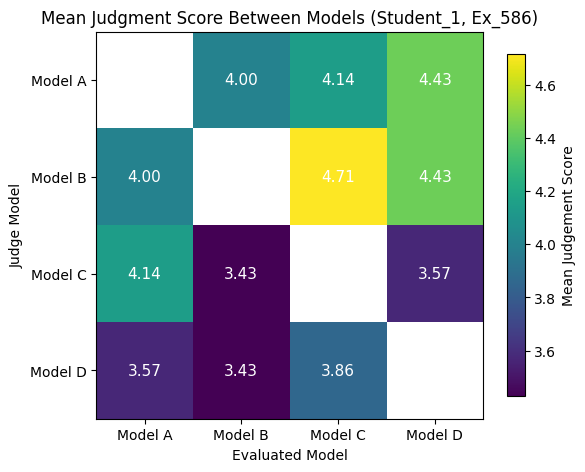

Wrote: Student_1_586_4x4_heatmap.png


In [ ]:
# matrix & heatmap of model judgement (Student_1, Ex_586)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILES = [
    "Llama_blind_pairwise_judgment_anonymized_Student_1_586_details.csv",
    "Gemini_blind_pairwise_judgment_anonymized_Student_1_586_details.csv",
    "Deepseek_blind_pairwise_judgment_anonymized_Student_1_586_details.csv",
    "GPT_blind_pairwise_judgment_anonymized_Student_1_586_details.csv",
]

ORDER = ["Model A", "Model B", "Model C", "Model D"]

OUT_MATRIX_CSV = "Student_1_586_4x4_judge_vs_eval_matrix.csv"
OUT_HEATMAP_PNG = "Student_1_586_4x4_heatmap.png"

dfs = []
for f in FILES:
    d = pd.read_csv(f)
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)

df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

agg = (
    df.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
      .mean()
      .reset_index()
)

heatmap_df = agg.pivot(
    index="judge_model_anon",
    columns="evaluated_model_anon",
    values="Judgement_score"
)

heatmap_df = heatmap_df.reindex(index=ORDER, columns=ORDER)

# Diagonal empty
for m in ORDER:
    if m in heatmap_df.index and m in heatmap_df.columns:
        heatmap_df.loc[m, m] = np.nan

print("4x4 matrix (mean judgement score):")
print(heatmap_df)

heatmap_df.to_csv(OUT_MATRIX_CSV, index=True)
print(f"Wrote: {OUT_MATRIX_CSV}")

plt.figure(figsize=(6, 6))

im = plt.imshow(heatmap_df.values, aspect="equal")
plt.colorbar(im, shrink=0.6, label="Mean Judgement Score")

plt.xticks(range(len(ORDER)), ORDER, ha="center")
plt.yticks(range(len(ORDER)), ORDER)

for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        val = heatmap_df.iloc[i, j]
        if not np.isnan(val):
            plt.text(
                j, i,
                f"{val:.2f}",
                ha="center",
                va="center",
                color="white",
                fontsize=11,
                #fontweight="bold"
            )

plt.xlabel("Evaluated Model")
plt.ylabel("Judge Model")
plt.title("Mean Judgment Score Between Models (Student_1, Ex_586)")
plt.tight_layout()
plt.savefig(OUT_HEATMAP_PNG, dpi=300)
plt.show()

print(f"Wrote: {OUT_HEATMAP_PNG}")


In [ ]:
# Llama

import os
import json
import re
import time
import requests
import pandas as pd

INPUT_FOLDERS = {
    "GPT": "./pairwise_judging_files/Student_snapshots_CT_analysis_GPT/",
    "Gemini": "./pairwise_judging_files/Student_snapshots_CT_analysis_Gemini/",
    "DeepSeek": "./pairwise_judging_files/Student_snapshots_CT_analysis_Deepseek/",
    "Llama": "./pairwise_judging_files/Student_snapshots_CT_analysis_Llama/",
}

JUDGE_MODEL = "Llama"

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

# Student_1_434_CT_analysis.json
FILENAME_TEMPLATE = "{student_id}_{assignment_id}_CT_analysis.json"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_ALL_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_ALL_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    if not text:
        return None
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except Exception:
            pass
    cleaned = text.replace("```json", "").replace("```", "")
    cleaned = cleaned.replace("\n", " ").replace("\t", " ")
    try:
        return json.loads(cleaned)
    except Exception:
        return None

def normalize_student_blob_for_prompt(base: dict):
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or s.get("code_snapshot") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

def safe_get(d: dict, *keys, default=""):
    for k in keys:
        if isinstance(d, dict) and k in d and d[k] is not None:
            return d[k]
    return default

def build_input_file_map(student_id: str, assignment_id: str):
    files = {}
    for model, folder in INPUT_FOLDERS.items():
        p1 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id, assignment_id=assignment_id))
        p2 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id.replace("_", ""), assignment_id=assignment_id))
        if os.path.exists(p1):
            files[model] = p1
        elif os.path.exists(p2):
            files[model] = p2
        else:
            return None  
    return files

# Blind Prompt
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5)
- Judgement_explanation

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt.strip()

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    return model.generate_content(prompt).text

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=180)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def main():
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FOLDERS.keys())

    all_results = []

    total_pairs = 0
    skipped_pairs = 0

    for student_id in STUDENTS:
        for assignment_id in ASSIGNMENTS:
            total_pairs += 1
            input_files = build_input_file_map(student_id, assignment_id)
            if input_files is None:
                skipped_pairs += 1
                print(f"[SKIP] Missing at least one model file for {student_id} / {assignment_id}")
                continue

            all_json = {k: load_json_file(v) for k, v in input_files.items()}

            base_raw = all_json.get(judge) or all_json[eval_models[0]]
            base = normalize_student_blob_for_prompt(base_raw)

            exercise_id = safe_get(base_raw, "exercise_id", "ExerciseID", "AssignmentID", "Assignment", default=assignment_id)
            topic = safe_get(base_raw, "topic", "Topic", default="")
            exercise_desc = safe_get(base_raw, "exercise_description", "ExerciseDescription", default="")
            sample_output = safe_get(base_raw, "sample_output", "SampleOutput", default="")

            for ev_model in eval_models:
                # skip self judgment
                if ev_model == judge:
                    continue

                evaluated_ct = all_json[ev_model].get("CT_analysis", [])
                if not evaluated_ct:
                    print(f"[WARN] No CT_analysis for {student_id}/{assignment_id} model={ev_model}")
                    continue

                prompt = build_prompt(
                    student=base,
                    exercise_id=exercise_id,
                    topic=topic,
                    exercise_description=exercise_desc,
                    sample_output=sample_output,
                    evaluated_ct_list=evaluated_ct
                )

                print(f"{student_id}/{assignment_id}: Judge {ANON_MODEL_MAP[judge]} evaluating {ANON_MODEL_MAP[ev_model]} ...")
                out = call_judge(prompt, judge)
                parsed = extract_json_array(out)

                if not parsed:
                    print(f"[WARN] Parse failed for {student_id}/{assignment_id} evaluated={ev_model}")
                    continue

                for item in parsed:
                    all_results.append({
                        "student_id": student_id,
                        "exercise_id": assignment_id,
                        "judge_model_anon": ANON_MODEL_MAP[judge],
                        "evaluated_model_anon": ANON_MODEL_MAP[ev_model],
                        "facet": item.get("facet"),
                        "Judgement_score": item.get("Judgement_score"),
                        "Judgement_explanation": item.get("Judgement_explanation"),
                    })

                time.sleep(0.5)  

    print(f"\nDone. Total pairs: {total_pairs}, skipped pairs: {skipped_pairs}")
    df = pd.DataFrame(all_results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    agg = (
        df.groupby(["judge_model_anon", "evaluated_model_anon", "facet"])["Judgement_score"]
          .mean()
          .reset_index()
    )
    agg.to_csv(OUTPUT_MATRIX_CSV, index=False)
    print(f"Saved matrix CSV (facet-level means): {OUTPUT_MATRIX_CSV}")

if __name__ == "__main__":
    main()


Student_1/434: Judge Model B evaluating Model A ...
Student_1/434: Judge Model B evaluating Model C ...
Student_1/434: Judge Model B evaluating Model D ...
Student_1/547: Judge Model B evaluating Model A ...
Student_1/547: Judge Model B evaluating Model C ...
Student_1/547: Judge Model B evaluating Model D ...
Student_1/568: Judge Model B evaluating Model A ...
Student_1/568: Judge Model B evaluating Model C ...
Student_1/568: Judge Model B evaluating Model D ...
Student_1/586: Judge Model B evaluating Model A ...
Student_1/586: Judge Model B evaluating Model C ...
Student_1/586: Judge Model B evaluating Model D ...
Student_1/683: Judge Model B evaluating Model A ...
Student_1/683: Judge Model B evaluating Model C ...
Student_1/683: Judge Model B evaluating Model D ...
Student_1/760: Judge Model B evaluating Model A ...
Student_1/760: Judge Model B evaluating Model C ...
Student_1/760: Judge Model B evaluating Model D ...
Student_1/1949: Judge Model B evaluating Model A ...
Student_1/1

In [ ]:
# Deepseek

import os
import json
import re
import time
import requests
import pandas as pd

INPUT_FOLDERS = {
    "GPT": "./pairwise_judging_files/Student_snapshots_CT_analysis_GPT/",
    "Gemini": "./pairwise_judging_files/Student_snapshots_CT_analysis_Gemini/",
    "DeepSeek": "./pairwise_judging_files/Student_snapshots_CT_analysis_Deepseek/",
    "Llama": "./pairwise_judging_files/Student_snapshots_CT_analysis_Llama/",
}

JUDGE_MODEL = "DeepSeek" 

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

START_STUDENT_NUM = 1  

# Student_1_434_CT_analysis.json
FILENAME_TEMPLATE = "{student_id}_{assignment_id}_CT_analysis.json"

# API keys
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"
DEEPSEEK_MODEL = "deepseek-chat"

REQUEST_TIMEOUT = 180
MAX_RETRIES = 2
RETRY_SLEEP_SECONDS = 2.0

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_ALL_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_ALL_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path: str):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def _extract_json_array_str(text: str):
    """More robust than regex: finds first top-level [...] block."""
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None

def extract_json_array(text: str):
    """Parse a JSON array from model output; returns list or None."""
    arr_str = _extract_json_array_str(text)
    if not arr_str:
        return None
    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return None

def normalize_student_blob_for_prompt(base: dict):
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = (
                s.get("CodeSnapshot")
                or s.get("CodeSnapshots")
                or s.get("code_snapshot")
                or ""
            )
        sid = s.get("snapshot_id")
        if sid is None:
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

def safe_get(d: dict, *keys, default=""):
    for k in keys:
        if isinstance(d, dict) and k in d and d[k] is not None:
            return d[k]
    return default

def student_num(student_id: str) -> int:
    m = re.search(r"(\d+)$", str(student_id))
    return int(m.group(1)) if m else 0

def build_input_file_map(student_id: str, assignment_id: str):
    """
    Returns dict model->path if ALL model files exist for this (student, assignment).
    If any missing -> None.
    """
    files = {}
    for model, folder in INPUT_FOLDERS.items():
        p1 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id, assignment_id=assignment_id))
        p2 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id.replace("_", ""), assignment_id=assignment_id))
        if os.path.exists(p1):
            files[model] = p1
        elif os.path.exists(p2):
            files[model] = p2
        else:
            return None
    return files

# PROMPT
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5)
- Judgement_explanation

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt.strip()

# DEEPSEEK CALLER (judge)
def call_deepseek(prompt: str) -> str:
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [
            {"role": "system", "content": "Return ONLY valid JSON array. No markdown. No extra text."},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0
    }

    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        try:
            r = requests.post(
                DEEPSEEK_API_URL,
                headers=headers,
                json=payload,
                timeout=REQUEST_TIMEOUT
            )
            r.raise_for_status()
            return r.json()["choices"][0]["message"]["content"]
        except Exception as e:
            last_err = e
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_SLEEP_SECONDS * (attempt + 1))
            else:
                raise last_err

def main():
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FOLDERS.keys())

    if judge != "DeepSeek":
        raise ValueError("This script is configured for DeepSeek as the judge. Set JUDGE_MODEL='DeepSeek'.")

    all_results = []

    total_pairs = 0
    skipped_pairs = 0

    for student_id in STUDENTS:
        if student_num(student_id) < START_STUDENT_NUM:
            continue

        for assignment_id in ASSIGNMENTS:
            total_pairs += 1

            input_files = build_input_file_map(student_id, assignment_id)
            if input_files is None:
                skipped_pairs += 1
                print(f"[SKIP] Missing at least one model file for {student_id} / {assignment_id}")
                continue

            all_json = {k: load_json_file(v) for k, v in input_files.items()}

            base_raw = all_json.get(judge) or all_json[eval_models[0]]
            base = normalize_student_blob_for_prompt(base_raw)

            exercise_id = safe_get(base_raw, "exercise_id", "ExerciseID", "AssignmentID", "Assignment", default=assignment_id)
            topic = safe_get(base_raw, "topic", "Topic", default="")
            exercise_desc = safe_get(base_raw, "exercise_description", "ExerciseDescription", default="")
            sample_output = safe_get(base_raw, "sample_output", "SampleOutput", default="")

            for ev_model in eval_models:
                # skip self judgment (diagonal)
                if ev_model == judge:
                    continue

                evaluated_ct = all_json[ev_model].get("CT_analysis", [])
                if not evaluated_ct:
                    print(f"[WARN] No CT_analysis for {student_id}/{assignment_id} model={ev_model}")
                    continue

                prompt = build_prompt(
                    student=base,
                    exercise_id=exercise_id,
                    topic=topic,
                    exercise_description=exercise_desc,
                    sample_output=sample_output,
                    evaluated_ct_list=evaluated_ct
                )

                print(f"{student_id}/{assignment_id}: Judge {ANON_MODEL_MAP[judge]} evaluating {ANON_MODEL_MAP[ev_model]} ...")
                out = call_deepseek(prompt)
                parsed = extract_json_array(out)


                if not parsed:
                    retry_prompt = prompt + "\n\nREMINDER: Output MUST be ONLY a JSON array. No extra text."
                    out2 = call_deepseek(retry_prompt)
                    parsed = extract_json_array(out2)

                if not parsed:
                    print(f"[WARN] Parse failed for {student_id}/{assignment_id} evaluated={ev_model}")
                    continue

                for item in parsed:
                    all_results.append({
                        "student_id": student_id,
                        "exercise_id": assignment_id, 
                        "judge_model_anon": ANON_MODEL_MAP[judge],
                        "evaluated_model_anon": ANON_MODEL_MAP[ev_model],
                        "facet": item.get("facet"),
                        "Judgement_score": item.get("Judgement_score"),
                        "Judgement_explanation": item.get("Judgement_explanation"),
                    })

                time.sleep(0.25)  

    print(f"\nDone. Total pairs: {total_pairs}, skipped pairs: {skipped_pairs}")
    df = pd.DataFrame(all_results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    if not df.empty:
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        agg = (
            df.groupby(["judge_model_anon", "evaluated_model_anon", "facet"])["Judgement_score"]
              .mean()
              .reset_index()
        )
        agg.to_csv(OUTPUT_MATRIX_CSV, index=False)
        print(f"Saved matrix CSV (facet-level means): {OUTPUT_MATRIX_CSV}")
    else:
        print("[WARN] No results were produced; matrix CSV not written.")

if __name__ == "__main__":
    main()


Student_1/434: Judge Model D evaluating Model A ...
Student_1/434: Judge Model D evaluating Model C ...
Student_1/434: Judge Model D evaluating Model B ...
Student_1/547: Judge Model D evaluating Model A ...
Student_1/547: Judge Model D evaluating Model C ...
Student_1/547: Judge Model D evaluating Model B ...
Student_1/568: Judge Model D evaluating Model A ...
Student_1/568: Judge Model D evaluating Model C ...
Student_1/568: Judge Model D evaluating Model B ...
Student_1/586: Judge Model D evaluating Model A ...
Student_1/586: Judge Model D evaluating Model C ...
Student_1/586: Judge Model D evaluating Model B ...
Student_1/683: Judge Model D evaluating Model A ...
Student_1/683: Judge Model D evaluating Model C ...
Student_1/683: Judge Model D evaluating Model B ...
Student_1/760: Judge Model D evaluating Model A ...
Student_1/760: Judge Model D evaluating Model C ...
Student_1/760: Judge Model D evaluating Model B ...
Student_1/1949: Judge Model D evaluating Model A ...
Student_1/1

In [ ]:
# GPT

import os
import json
import re
import time
import pandas as pd
from openai import OpenAI

INPUT_FOLDERS = {
    "GPT": "./pairwise_judging_files/Student_snapshots_CT_analysis_GPT/",
    "Gemini": "./pairwise_judging_files/Student_snapshots_CT_analysis_Gemini/",
    "DeepSeek": "./pairwise_judging_files/Student_snapshots_CT_analysis_Deepseek/",
    "Llama": "./pairwise_judging_files/Student_snapshots_CT_analysis_Llama/",
}

JUDGE_MODEL = "GPT" 

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

START_STUDENT_NUM = 1 

# Student_1_434_CT_analysis.json
FILENAME_TEMPLATE = "{student_id}_{assignment_id}_CT_analysis.json"

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL_NAME = "gpt-5.1"  # per your setup

REQUEST_TIMEOUT = 180
MAX_RETRIES = 2
RETRY_SLEEP_SECONDS = 2.0

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_ALL_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_ALL_matrix.csv"

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path: str):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def _extract_json_array_str(text: str):
    """Find first top-level JSON array block [...] in model output."""
    if not text:
        return None
    start = text.find("[")
    if start == -1:
        return None

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]
    return None

def extract_json_array(text: str):
    arr_str = _extract_json_array_str(text)
    if not arr_str:
        return None
    try:
        return json.loads(arr_str)
    except json.JSONDecodeError:
        repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            return None

def normalize_student_blob_for_prompt(base: dict):
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = (
                s.get("CodeSnapshot")
                or s.get("CodeSnapshots")
                or s.get("code_snapshot")
                or ""
            )
        sid = s.get("snapshot_id")
        if sid is None:
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

def safe_get(d: dict, *keys, default=""):
    for k in keys:
        if isinstance(d, dict) and k in d and d[k] is not None:
            return d[k]
    return default

def student_num(student_id: str) -> int:
    m = re.search(r"(\d+)$", str(student_id))
    return int(m.group(1)) if m else 0

def build_input_file_map(student_id: str, assignment_id: str):
    """
    Returns dict model->path if ALL model files exist for this (student, assignment).
    If any missing -> None.
    """
    files = {}
    for model, folder in INPUT_FOLDERS.items():
        p1 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id, assignment_id=assignment_id))
        p2 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id.replace("_", ""), assignment_id=assignment_id))
        if os.path.exists(p1):
            files[model] = p1
        elif os.path.exists(p2):
            files[model] = p2
        else:
            return None
    return files

# PROMPT
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5)
- Judgement_explanation

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt.strip()

# GPT CALLER (judge)
def call_gpt(prompt: str) -> str:
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")

    client = OpenAI(api_key=OPENAI_API_KEY)

    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        try:
            r = client.chat.completions.create(
                model=OPENAI_MODEL_NAME,
                messages=[
                    {"role": "system", "content": "Return ONLY valid JSON array. No markdown. No extra text."},
                    {"role": "user", "content": prompt},
                ],
                temperature=0,
            )
            return r.choices[0].message.content
        except Exception as e:
            last_err = e
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_SLEEP_SECONDS * (attempt + 1))
            else:
                raise last_err

def main():
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FOLDERS.keys())

    if judge != "GPT":
        raise ValueError("This script is configured for GPT as the judge. Set JUDGE_MODEL='GPT'.")

    all_results = []

    total_pairs = 0
    skipped_pairs = 0

    for student_id in STUDENTS:
        if student_num(student_id) < START_STUDENT_NUM:
            continue

        for assignment_id in ASSIGNMENTS:
            total_pairs += 1

            input_files = build_input_file_map(student_id, assignment_id)
            if input_files is None:
                skipped_pairs += 1
                print(f"[SKIP] Missing at least one model file for {student_id} / {assignment_id}")
                continue

            all_json = {k: load_json_file(v) for k, v in input_files.items()}

            base_raw = all_json.get(judge) or all_json[eval_models[0]]
            base = normalize_student_blob_for_prompt(base_raw)

            exercise_id = safe_get(base_raw, "exercise_id", "ExerciseID", "AssignmentID", "Assignment", default=assignment_id)
            topic = safe_get(base_raw, "topic", "Topic", default="")
            exercise_desc = safe_get(base_raw, "exercise_description", "ExerciseDescription", default="")
            sample_output = safe_get(base_raw, "sample_output", "SampleOutput", default="")

            for ev_model in eval_models:
                # skip self judgment (diagonal)
                if ev_model == judge:
                    continue

                evaluated_ct = all_json[ev_model].get("CT_analysis", [])
                if not evaluated_ct:
                    print(f"[WARN] No CT_analysis for {student_id}/{assignment_id} model={ev_model}")
                    continue

                prompt = build_prompt(
                    student=base,
                    exercise_id=exercise_id,
                    topic=topic,
                    exercise_description=exercise_desc,
                    sample_output=sample_output,
                    evaluated_ct_list=evaluated_ct
                )

                print(f"{student_id}/{assignment_id}: Judge {ANON_MODEL_MAP[judge]} evaluating {ANON_MODEL_MAP[ev_model]} ...")
                out = call_gpt(prompt)
                parsed = extract_json_array(out)

                if not parsed:
                    retry_prompt = prompt + "\n\nREMINDER: Output MUST be ONLY a JSON array. No extra text."
                    out2 = call_gpt(retry_prompt)
                    parsed = extract_json_array(out2)

                if not parsed:
                    print(f"[WARN] Parse failed for {student_id}/{assignment_id} evaluated={ev_model}")
                    continue

                for item in parsed:
                    all_results.append({
                        "student_id": student_id,
                        "exercise_id": assignment_id,  
                        "judge_model_anon": ANON_MODEL_MAP[judge],
                        "evaluated_model_anon": ANON_MODEL_MAP[ev_model],
                        "facet": item.get("facet"),
                        "Judgement_score": item.get("Judgement_score"),
                        "Judgement_explanation": item.get("Judgement_explanation"),
                    })

                time.sleep(0.25) 

    print(f"\nDone. Total pairs: {total_pairs}, skipped pairs: {skipped_pairs}")
    df = pd.DataFrame(all_results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    if not df.empty:
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        agg = (
            df.groupby(["judge_model_anon", "evaluated_model_anon", "facet"])["Judgement_score"]
              .mean()
              .reset_index()
        )
        agg.to_csv(OUTPUT_MATRIX_CSV, index=False)
        print(f"Saved matrix CSV (facet-level means): {OUTPUT_MATRIX_CSV}")
    else:
        print("[WARN] No results were produced; matrix CSV not written.")

if __name__ == "__main__":
    main()


Student_1/434: Judge Model A evaluating Model C ...
Student_1/434: Judge Model A evaluating Model D ...
Student_1/434: Judge Model A evaluating Model B ...
Student_1/547: Judge Model A evaluating Model C ...
Student_1/547: Judge Model A evaluating Model D ...
Student_1/547: Judge Model A evaluating Model B ...
Student_1/568: Judge Model A evaluating Model C ...
Student_1/568: Judge Model A evaluating Model D ...
Student_1/568: Judge Model A evaluating Model B ...
Student_1/586: Judge Model A evaluating Model C ...
Student_1/586: Judge Model A evaluating Model D ...
Student_1/586: Judge Model A evaluating Model B ...
Student_1/683: Judge Model A evaluating Model C ...
Student_1/683: Judge Model A evaluating Model D ...
Student_1/683: Judge Model A evaluating Model B ...
Student_1/760: Judge Model A evaluating Model C ...
Student_1/760: Judge Model A evaluating Model D ...
Student_1/760: Judge Model A evaluating Model B ...
Student_1/1949: Judge Model A evaluating Model C ...
Student_1/1

In [ ]:
# Gemini (edited)

import os
import json
import re
import time
import random
import requests
import pandas as pd

INPUT_FOLDERS = {
    "GPT": "./pairwise_judging_files/Student_snapshots_CT_analysis_GPT/",
    "Gemini": "./pairwise_judging_files/Student_snapshots_CT_analysis_Gemini/",
    "DeepSeek": "./pairwise_judging_files/Student_snapshots_CT_analysis_Deepseek/",
    "Llama": "./pairwise_judging_files/Student_snapshots_CT_analysis_Llama/",
}

JUDGE_MODEL = "Gemini"

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

START_STUDENT_NUM = 1

FILENAME_TEMPLATE = "{student_id}_{assignment_id}_CT_analysis.json"

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

OPENAI_MODEL_NAME = "gpt-5.1"
GEMINI_MODEL_NAME = "gemini-2.5-flash"
GROQ_MODEL_NAME   = "llama-3.3-70b-versatile"
DEEPSEEK_MODEL    = "deepseek-chat"

OUTPUT_DETAIL_CSV = f"{JUDGE_MODEL}_blind_pairwise_judgment_anonymized_ALL_details.csv"
OUTPUT_MATRIX_CSV = f"{JUDGE_MODEL}_blind_pairwise_agreement_anonymized_ALL_matrix.csv"

GEMINI_REQUEST_TIMEOUT_SECONDS = 300 
MAX_RETRIES = 4                       
BASE_BACKOFF_SECONDS = 3.0            
JITTER_SECONDS = 1.0                  
INTER_CALL_SLEEP = 0.6                

# Likert mapping
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ANON_MODEL_MAP = {
    "GPT": "Model A",
    "Llama": "Model B",
    "Gemini": "Model C",
    "DeepSeek": "Model D"
}

# Computational Thinking Facets
CT_FACETS = {
    "Decomposition": "Breaking a complex problem into smaller, manageable subproblems or functional components. It involves dividing the overall task into logical parts such as designing helper functions, separating base and recursive cases, or structuring a program into input, processing, and output phases.",
    "Abstraction": "Identifying essential features or principles of a problem while filtering out unnecessary details. Students demonstrate abstraction when they recognize the underlying logic that governs a problem (e.g., the recursive structure of Fibonacci), use meaningful variable names to represent concepts, or generalize from specific examples to broader rules.",
    "Pattern Recognition": "Recognizing similarities, recurring structures, or relationships across problems or within code. In code, pattern recognition may appear as reusing familiar structures (loops, recursion, conditionals), recognizing repeated logic, or applying a known problem-solving template.",
    "Algorithms": "Designing and implementing a clear, step-by-step procedure or set of rules to solve a problem. Students exhibit algorithmic thinking when they create or adapt a systematic approach to reach the correct output, ensuring that each step logically follows from the previous one.",
    "Debugging": "Detecting, analyzing, and correcting errors or unexpected behavior in a program to achieve the desired output. In process data, debugging can appear as multiple code revisions, added print statements, or gradual corrections to logic errors.",
    "Iteration": "Refining and improving a solution through repeated cycles of testing, evaluation, and modification. Iteration may occur both within the program (loops or recursive calls) and in the programming process (repeatedly revising code until it works correctly).",
    "Generalization": "Extending a learned principle, pattern, or algorithm from one context to another. It reflects the ability to apply a solution approach to new problems or adapt it to handle a broader range of inputs."
}

# Proficiency Levels
PROFICIENCY_LEVELS = {
    1: "Not Proficient : The student does not demonstrate understanding of this CT facet or applies it incorrectly.",
    2: "Emerging : The student shows limited awareness of this facet, but their application is inconsistent or incomplete.",
    3: "Developing : The student demonstrates partial understanding of this facet, applying it in some contexts but not consistently.",
    4: "Proficient : The student shows a solid understanding and effective use of this facet in most contexts.",
    5: "Highly Proficient : The student consistently applies this facet correctly and demonstrates deep understanding or transfer of skill."
}

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data[0] if isinstance(data, list) and data else data

def extract_json_array(text):
    """Robustly extract the first top-level JSON array from model output."""
    if not text:
        return None

    start = text.find("[")
    if start != -1:
        depth = 0
        in_str = False
        esc = False
        for i in range(start, len(text)):
            ch = text[i]
            if in_str:
                if esc:
                    esc = False
                elif ch == "\\":
                    esc = True
                elif ch == '"':
                    in_str = False
            else:
                if ch == '"':
                    in_str = True
                elif ch == "[":
                    depth += 1
                elif ch == "]":
                    depth -= 1
                    if depth == 0:
                        arr_str = text[start:i + 1]
                        try:
                            return json.loads(arr_str)
                        except json.JSONDecodeError:
                            repaired = re.sub(r'\\(?!["\\/bfnrtu])', r'\\\\', arr_str)
                            try:
                                return json.loads(repaired)
                            except json.JSONDecodeError:
                                return None

    cleaned = text.replace("```json", "").replace("```", "")
    cleaned = cleaned.replace("\n", " ").replace("\t", " ")
    try:
        return json.loads(cleaned)
    except Exception:
        return None

def normalize_student_blob_for_prompt(base: dict):
    """
    Ensure prompt uses:
      base["snapshots"] = [{"snapshot_id":..., "code":...}, ...]
    """
    snapshots = base.get("snapshots", []) or []
    out = []
    for i, s in enumerate(snapshots, start=1):
        if not isinstance(s, dict):
            continue
        code = s.get("code")
        if code is None:
            code = s.get("CodeSnapshot") or s.get("CodeSnapshots") or s.get("code_snapshot") or ""
        sid = s.get("snapshot_id")
        if sid is None:
            sid = s.get("StartTime") or s.get("snapshot_time") or i
        out.append({"snapshot_id": sid, "code": code})
    base2 = dict(base)
    base2["snapshots"] = out
    return base2

def safe_get(d: dict, *keys, default=""):
    for k in keys:
        if isinstance(d, dict) and k in d and d[k] is not None:
            return d[k]
    return default

def student_num(student_id: str) -> int:
    m = re.search(r"(\d+)$", str(student_id))
    return int(m.group(1)) if m else 0

def build_input_file_map(student_id: str, assignment_id: str):
    files = {}
    for model, folder in INPUT_FOLDERS.items():
        p1 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id, assignment_id=assignment_id))
        p2 = os.path.join(folder, FILENAME_TEMPLATE.format(student_id=student_id.replace("_", ""), assignment_id=assignment_id))
        if os.path.exists(p1):
            files[model] = p1
        elif os.path.exists(p2):
            files[model] = p2
        else:
            return None  
    return files

# PROMPT
def build_prompt(student,
                 exercise_id,
                 topic,
                 exercise_description,
                 sample_output,
                 evaluated_ct_list):

    snapshots_text = "\n\n".join(
        [f"Snapshot {s.get('snapshot_id')}:\n{s.get('code','')}"
         for s in student.get("snapshots", [])]
    )

    prompt = f"""
You are a CS education researcher specializing in computational thinking (CT).

You will evaluate Model X (unknown to you) that assessed computational thinking of a student's programming process.
Your job is to judge how accurate Model X's assessment is.

Important rules:
- Judge ONLY based on correctness and evidence.
- If you use language in judgment explanation such as "agree", "mostly agree", or "the model is correct",
  your Judgement_score MUST be 4 or 5.
- If you use language in judgment explanation such as "disagree", "incorrect", or "overestimates",
  your Judgement_score MUST be 1 or 2.
- Do NOT mix agreement language with disagreement scores.

### Exercise
ID: {exercise_id}
Topic: {topic}
Description: {exercise_description}
Sample Output: {sample_output}

### Computational Thinking Assessment Done by Model X
{json.dumps(evaluated_ct_list, indent=2)}

### Student Code Snapshots
{snapshots_text}

### Computational Thinking Facet Definitions
{json.dumps(CT_FACETS, indent=2)}

### Proficiency Levels Specified by Model X
{json.dumps(PROFICIENCY_LEVELS, indent=2)}

### Likert Scale
{json.dumps(LIKERT_MAP, indent=2)}

### Task
For EACH CT facet, produce:
- facet
- Judgement_score (1–5)
- Judgement_explanation

### Output JSON (ONLY JSON; no markdown; no extra text)
[
  {{
    "facet": "<facet_name>",
    "Judgement_score": <1-5>,
    "Judgement_explanation": "<text>"
  }}
]
"""
    return prompt.strip()

def call_openai(prompt):
    from openai import OpenAI
    if not OPENAI_API_KEY:
        raise ValueError("OPENAI_API_KEY not set")
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_gemini(prompt):
    import google.generativeai as genai
    import google.api_core.exceptions as gexc

    if not GEMINI_API_KEY:
        raise ValueError("GOOGLE_API_KEY not set")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)

    try:
        resp = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(temperature=0.0),
            request_options={"timeout": GEMINI_REQUEST_TIMEOUT_SECONDS},
        )
        return (resp.text or "").strip()
    except gexc.DeadlineExceeded as e:
        raise e

def call_groq(prompt):
    from groq import Groq
    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not set")
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content

def call_deepseek(prompt):
    if not DEEPSEEK_API_KEY:
        raise ValueError("DEEPSEEK_API_KEY not set")
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }
    r = requests.post(DEEPSEEK_API_URL, headers=headers, json=payload, timeout=240)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def call_judge_raw(prompt, judge):
    if judge == "GPT": return call_openai(prompt)
    if judge == "Gemini": return call_gemini(prompt)
    if judge == "Llama": return call_groq(prompt)
    if judge == "DeepSeek": return call_deepseek(prompt)
    raise ValueError("Invalid judge")

def is_retryable_error(e: Exception) -> bool:
    msg = str(e).lower()
    retry_keywords = [
        "deadline exceeded",
        "504",
        "gateway",
        "timeout",
        "temporarily unavailable",
        "resource exhausted",
        "rate limit",
        "internal",
        "unavailable",
        "connection reset",
        "connection aborted",
        "read timed out",
    ]
    return any(k in msg for k in retry_keywords)

def call_judge_with_retries(prompt: str, judge: str) -> str:
    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        try:
            return call_judge_raw(prompt, judge)
        except Exception as e:
            last_err = e
            if attempt >= MAX_RETRIES or not is_retryable_error(e):
                raise
            sleep_s = (BASE_BACKOFF_SECONDS * (2 ** attempt)) + random.uniform(0, JITTER_SECONDS)
            print(f"[RETRY] {judge} failed ({type(e).__name__}: {e}). Sleeping {sleep_s:.1f}s then retry...")
            time.sleep(sleep_s)
    raise last_err

def main():
    judge = JUDGE_MODEL
    eval_models = list(INPUT_FOLDERS.keys())

    all_results = []
    total_pairs = 0
    skipped_pairs = 0

    for student_id in STUDENTS:
        if student_num(student_id) < START_STUDENT_NUM:
            continue

        for assignment_id in ASSIGNMENTS:
            total_pairs += 1
            input_files = build_input_file_map(student_id, assignment_id)
            if input_files is None:
                skipped_pairs += 1
                print(f"[SKIP] Missing at least one model file for {student_id} / {assignment_id}")
                continue

            all_json = {k: load_json_file(v) for k, v in input_files.items()}

            base_raw = all_json.get(judge) or all_json[eval_models[0]]
            base = normalize_student_blob_for_prompt(base_raw)

            exercise_id = safe_get(base_raw, "exercise_id", "ExerciseID", "AssignmentID", "Assignment", default=assignment_id)
            topic = safe_get(base_raw, "topic", "Topic", default="")
            exercise_desc = safe_get(base_raw, "exercise_description", "ExerciseDescription", default="")
            sample_output = safe_get(base_raw, "sample_output", "SampleOutput", default="")

            for ev_model in eval_models:
                # skip self-judgment
                if ev_model == judge:
                    continue

                evaluated_ct = all_json[ev_model].get("CT_analysis", [])
                if not evaluated_ct:
                    print(f"[WARN] No CT_analysis for {student_id}/{assignment_id} model={ev_model}")
                    continue

                prompt = build_prompt(
                    student=base,
                    exercise_id=exercise_id,
                    topic=topic,
                    exercise_description=exercise_desc,
                    sample_output=sample_output,
                    evaluated_ct_list=evaluated_ct
                )

                print(f"{student_id}/{assignment_id}: Judge {ANON_MODEL_MAP[judge]} evaluating {ANON_MODEL_MAP[ev_model]} ...")

                out = call_judge_with_retries(prompt, judge)
                parsed = extract_json_array(out)

                if not parsed:
                    retry_prompt = prompt + "\n\nREMINDER: Output MUST be ONLY a JSON array. No extra text."
                    out2 = call_judge_with_retries(retry_prompt, judge)
                    parsed = extract_json_array(out2)

                if not parsed:
                    print(f"[WARN] Parse failed for {student_id}/{assignment_id} evaluated={ev_model}")
                    continue

                for item in parsed:
                    all_results.append({
                        "student_id": student_id,
                        "exercise_id": assignment_id,
                        "judge_model_anon": ANON_MODEL_MAP[judge],
                        "evaluated_model_anon": ANON_MODEL_MAP[ev_model],
                        "facet": item.get("facet"),
                        "Judgement_score": item.get("Judgement_score"),
                        "Judgement_explanation": item.get("Judgement_explanation"),
                    })

                time.sleep(INTER_CALL_SLEEP)

    print(f"\nDone. Total pairs: {total_pairs}, skipped pairs: {skipped_pairs}")
    df = pd.DataFrame(all_results)
    df.to_csv(OUTPUT_DETAIL_CSV, index=False)
    print(f"Saved detail CSV: {OUTPUT_DETAIL_CSV}")

    if not df.empty:
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        agg = (
            df.groupby(["judge_model_anon", "evaluated_model_anon", "facet"])["Judgement_score"]
              .mean()
              .reset_index()
        )
        agg.to_csv(OUTPUT_MATRIX_CSV, index=False)
        print(f"Saved matrix CSV (facet-level means): {OUTPUT_MATRIX_CSV}")
    else:
        print("[WARN] No results produced; matrix CSV not written.")

if __name__ == "__main__":
    main()


Student_1/434: Judge Model C evaluating Model A ...
Student_1/434: Judge Model C evaluating Model D ...
Student_1/434: Judge Model C evaluating Model B ...
Student_1/547: Judge Model C evaluating Model A ...
Student_1/547: Judge Model C evaluating Model D ...
Student_1/547: Judge Model C evaluating Model B ...
Student_1/568: Judge Model C evaluating Model A ...
Student_1/568: Judge Model C evaluating Model D ...
Student_1/568: Judge Model C evaluating Model B ...
Student_1/586: Judge Model C evaluating Model A ...
Student_1/586: Judge Model C evaluating Model D ...
Student_1/586: Judge Model C evaluating Model B ...
Student_1/683: Judge Model C evaluating Model A ...
Student_1/683: Judge Model C evaluating Model D ...
Student_1/683: Judge Model C evaluating Model B ...
Student_1/760: Judge Model C evaluating Model A ...
Student_1/760: Judge Model C evaluating Model D ...
Student_1/760: Judge Model C evaluating Model B ...
Student_1/1949: Judge Model C evaluating Model A ...
Student_1/1

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DETAILS_FOLDER = "./pairwise_judging_files/"   
OUT_FOLDER = "./pairwise_judging_files/matrices/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

JUDGES = ["GPT", "Llama", "Gemini", "Deepseek"]  

ORDER = ["Model A", "Model B", "Model C", "Model D"]

MAKE_HEATMAP = True

# Heatmap display settings
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6 

def find_detail_csv(judge_name: str, student_id: str, assignment_id: str):
    """
    Find file like:
      {judge}_blind_pairwise_judgment_anonymized_Student_1_586_details.csv
    anywhere in DETAILS_FOLDER.
    """
    pattern = rf"^{re.escape(judge_name)}_blind_pairwise_judgment_anonymized_{re.escape(student_id)}_{re.escape(assignment_id)}_details\.csv$"
    for fn in os.listdir(DETAILS_FOLDER):
        if re.match(pattern, fn, flags=re.IGNORECASE):
            return os.path.join(DETAILS_FOLDER, fn)
    return None

def build_matrix_for_pair(student_id: str, assignment_id: str):
    """
    Build 4x4 matrix where rows=judge_model_anon, cols=evaluated_model_anon
    values = mean Judgement_score over facets (for that judge/evaluated pair)
    diagonal left NaN
    """
    all_parts = []

    for judge in JUDGES:
        path = find_detail_csv(judge, student_id, assignment_id)
        if not path:
            print(f"[SKIP] Missing detail CSV for judge={judge}: {student_id}/{assignment_id}")
            return None, None

        df = pd.read_csv(path)

        req = {"judge_model_anon", "evaluated_model_anon", "facet", "Judgement_score"}
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{os.path.basename(path)} missing columns: {missing}")

        # mean over facets for each (judge, evaluated)
        agg = (
            df.groupby(["judge_model_anon", "evaluated_model_anon"])["Judgement_score"]
              .mean()
              .reset_index()
        )
        all_parts.append(agg)

    combined = pd.concat(all_parts, ignore_index=True)

    mat = combined.pivot_table(
        index="judge_model_anon",
        columns="evaluated_model_anon",
        values="Judgement_score",
        aggfunc="mean"
    )

    mat = mat.reindex(index=ORDER, columns=ORDER)

    # Diagonal empty
    for m in ORDER:
        if m in mat.index and m in mat.columns:
            mat.loc[m, m] = np.nan

    out_csv = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.csv")
    mat.to_csv(out_csv, index=True)
    return mat, out_csv

def draw_heatmap(mat: pd.DataFrame, student_id: str, assignment_id: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, aspect="auto")

    # ticks/labels
    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, rotation=30, ha="right")
    ax.set_yticklabels(ORDER)
    ax.set_title(f"Pairwise Judgement Mean\n{student_id} / {assignment_id}")
    ax.set_xlabel("Evaluated Model")
    ax.set_ylabel("Judge Model")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Mean Judgement Score (1–5)")

    import matplotlib.colors as mcolors
    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)

    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=11,
                    fontweight="bold"
                )

    ax.set_xticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    out_png = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    return out_png

for student_id in STUDENTS:
    for assignment_id in ASSIGNMENTS:
        mat, out_csv = build_matrix_for_pair(student_id, assignment_id)
        if mat is None:
            continue

        print(f"[OK] Wrote matrix CSV: {out_csv}")

        if MAKE_HEATMAP:
            out_png = draw_heatmap(mat, student_id, assignment_id)
            print(f"     Wrote heatmap PNG: {out_png}")


[SKIP] Missing detail CSV for judge=GPT: Student_1/434
[SKIP] Missing detail CSV for judge=GPT: Student_1/547
[SKIP] Missing detail CSV for judge=GPT: Student_1/568
[SKIP] Missing detail CSV for judge=GPT: Student_1/586
[SKIP] Missing detail CSV for judge=GPT: Student_1/683
[SKIP] Missing detail CSV for judge=GPT: Student_1/760
[SKIP] Missing detail CSV for judge=GPT: Student_1/1949
[SKIP] Missing detail CSV for judge=GPT: Student_1/2135
[SKIP] Missing detail CSV for judge=GPT: Student_1/2171
[SKIP] Missing detail CSV for judge=GPT: Student_2/434
[SKIP] Missing detail CSV for judge=GPT: Student_2/547
[SKIP] Missing detail CSV for judge=GPT: Student_2/568
[SKIP] Missing detail CSV for judge=GPT: Student_2/586
[SKIP] Missing detail CSV for judge=GPT: Student_2/683
[SKIP] Missing detail CSV for judge=GPT: Student_2/760
[SKIP] Missing detail CSV for judge=GPT: Student_2/1949
[SKIP] Missing detail CSV for judge=GPT: Student_2/2135
[SKIP] Missing detail CSV for judge=GPT: Student_2/2171
[SKI

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

ORDER = ["Model A", "Model B", "Model C", "Model D"]

MAKE_HEATMAP = True
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6  # smaller colorbar

JUDGE_NAME_NORMALIZE = {
    "Deepseek": "DeepSeek",
    "deepseek": "DeepSeek",
}

def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        # required columns (student/exercise + judgement cols)
        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        df = df[list(req)].copy()

        df["judge_file"] = judge_name

        parts.append(df)

    all_df = pd.concat(parts, ignore_index=True)
    all_df["judge_file"] = all_df["judge_file"].replace(JUDGE_NAME_NORMALIZE)

    return all_df


DETAILS_DF = load_all_details()

def build_matrix_for_pair(student_id: str, assignment_id: str):
    """
    Build 4x4 matrix:
      rows = judge_model_anon
      cols = evaluated_model_anon
      values = mean Judgement_score over facets
    diagonal NaN
    """
    sub = DETAILS_DF[
        (DETAILS_DF["student_id"] == student_id) &
        (DETAILS_DF["exercise_id"].astype(str) == str(assignment_id))
    ].copy()

    if sub.empty:
        return None, None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
           .mean()
           .reset_index()
    )

    mat = agg.pivot(
        index="judge_model_anon",
        columns="evaluated_model_anon",
        values="Judgement_score"
    )

    mat = mat.reindex(index=ORDER, columns=ORDER)

    # diagonal empty
    for m in ORDER:
        if m in mat.index and m in mat.columns:
            mat.loc[m, m] = np.nan

    out_csv = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.csv")
    mat.to_csv(out_csv, index=True)
    return mat, out_csv

# HEATMAP 
def draw_heatmap(mat: pd.DataFrame, student_id: str, assignment_id: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, aspect="auto")

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, rotation=30, ha="right")
    ax.set_yticklabels(ORDER)

    ax.set_title(f"Pairwise Judgement Mean\n{student_id} / {assignment_id}")
    ax.set_xlabel("Evaluated Model")
    ax.set_ylabel("Judge Model")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Mean Judgement Score (1–5)")

    import matplotlib.colors as mcolors
    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)

    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=11,
                    fontweight="bold",
                )

    ax.set_xticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    out_png = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    return out_png

for student_id in STUDENTS:
    for assignment_id in ASSIGNMENTS:
        mat, out_csv = build_matrix_for_pair(student_id, assignment_id)
        if mat is None:
            print(f"[SKIP] No rows found for {student_id}/{assignment_id} in ALL detail CSVs")
            continue

        print(f"[OK] Wrote matrix CSV: {out_csv}")

        if MAKE_HEATMAP:
            out_png = draw_heatmap(mat, student_id, assignment_id)
            print(f"     Wrote heatmap PNG: {out_png}")


[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_434.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_434.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_547.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_547.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_568.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_568.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_586.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_586.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_683.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_683.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_76

In [ ]:
# NON anonymized
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

ORDER = ["Model A", "Model B", "Model C", "Model D"]

USE_DISPLAY_LABELS = True
DISPLAY_LABELS = {
    "Model A": "GPT",
    "Model B": "Llama",
    "Model C": "Gemini",
    "Model D": "DeepSeek",
}

MAKE_HEATMAP = True
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6

HEATMAP_CMAP_NAME = "YlGnBu"   .
NAN_COLOR = "white"

TITLE_SIZE = 18
AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
COLORBAR_LABEL_SIZE = 14
COLORBAR_TICK_SIZE = 12
CELL_TEXT_SIZE = 12

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
})

def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df = df[list(req)].copy()
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")
        df["student_id"] = df["student_id"].astype(str)
        df["exercise_id"] = df["exercise_id"].astype(str)

        parts.append(df)

    return pd.concat(parts, ignore_index=True)


DETAILS_DF = load_all_details()

def build_matrix_for_pair(student_id: str, assignment_id: str):
    sub = DETAILS_DF[
        (DETAILS_DF["student_id"] == str(student_id)) &
        (DETAILS_DF["exercise_id"] == str(assignment_id))
    ].copy()

    if sub.empty:
        return None, None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
           .mean()
           .reset_index()
    )

    mat = agg.pivot(
        index="judge_model_anon",
        columns="evaluated_model_anon",
        values="Judgement_score"
    ).reindex(index=ORDER, columns=ORDER)

    # diagonal empty
    for m in ORDER:
        mat.loc[m, m] = np.nan

    out_csv = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.csv")
    mat.to_csv(out_csv, index=True)
    return mat, out_csv

# HEATMAP 
def draw_heatmap(mat: pd.DataFrame, student_id: str, assignment_id: str):
    fig, ax = plt.subplots(figsize=(6, 5))

    cmap = plt.get_cmap(HEATMAP_CMAP_NAME).copy()
    cmap.set_bad(color=NAN_COLOR)

    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, cmap=cmap, aspect="auto")

    xlabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER
    ylabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(xlabels, ha="center", fontsize=TICK_LABEL_SIZE)
    ax.set_yticklabels(ylabels, fontsize=TICK_LABEL_SIZE)

    ax.set_title(
        f"Pairwise Judgement\n{student_id} / {assignment_id}",
        fontsize=TITLE_SIZE,
        fontweight="bold",
    )
    ax.set_xlabel("Evaluated Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("Judge Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Mean Judgement Score (1–5)", fontsize=COLORBAR_LABEL_SIZE, fontweight="bold")
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)

    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color=text_color,
                    fontsize=CELL_TEXT_SIZE,
                    fontweight="bold"
                )

    ax.grid(False)

    out_png = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    return out_png

for student_id in STUDENTS:
    for assignment_id in ASSIGNMENTS:
        mat, out_csv = build_matrix_for_pair(student_id, assignment_id)
        if mat is None:
            print(f"[SKIP] No rows found for {student_id}/{assignment_id} in ALL detail CSVs")
            continue

        print(f"[OK] Wrote matrix CSV: {out_csv}")

        if MAKE_HEATMAP:
            out_png = draw_heatmap(mat, student_id, assignment_id)
            print(f"     Wrote heatmap PNG: {out_png}")


[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_434.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_434.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_547.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_547.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_568.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_568.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_586.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_586.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_683.csv
     Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_683.png
[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_Student_1_76

In [ ]:
# All anonymized

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices_by_facet/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

ORDER = ["Model A", "Model B", "Model C", "Model D"]

MAKE_HEATMAP = True
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6

JUDGE_NAME_NORMALIZE = {"Deepseek": "DeepSeek", "deepseek": "DeepSeek"}

def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df = df[list(req)].copy()
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")
        df["judge_file"] = judge_name
        parts.append(df)

    all_df = pd.concat(parts, ignore_index=True)
    all_df["judge_file"] = all_df["judge_file"].replace(JUDGE_NAME_NORMALIZE)
    all_df["exercise_id"] = all_df["exercise_id"].astype(str)
    return all_df


DETAILS_DF = load_all_details()

FACETS = sorted([f for f in DETAILS_DF["facet"].dropna().unique().tolist()])

def build_matrix_for_pair_facet(student_id: str, assignment_id: str, facet: str):
    sub = DETAILS_DF[
        (DETAILS_DF["student_id"] == student_id) &
        (DETAILS_DF["exercise_id"] == str(assignment_id)) &
        (DETAILS_DF["facet"] == facet)
    ].copy()

    if sub.empty:
        return None, None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
           .mean()
           .reset_index()
    )

    mat = agg.pivot(
        index="judge_model_anon",
        columns="evaluated_model_anon",
        values="Judgement_score"
    ).reindex(index=ORDER, columns=ORDER)

    # diagonal empty
    for m in ORDER:
        if m in mat.index and m in mat.columns:
            mat.loc[m, m] = np.nan

    safe_facet = facet.replace("/", "_").replace(" ", "_")
    out_csv = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}_{safe_facet}.csv")
    mat.to_csv(out_csv, index=True)
    return mat, out_csv

# HEATMAP
def draw_heatmap(mat: pd.DataFrame, student_id: str, assignment_id: str, facet: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, aspect="auto")

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, rotation=30, ha="right")
    ax.set_yticklabels(ORDER)

    ax.set_title(f"{facet}\n{student_id} / {assignment_id}")
    ax.set_xlabel("Evaluated Model")
    ax.set_ylabel("Judge Model")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Judgement Score (1–5)")

    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color=text_color,
                    fontsize=11, fontweight="bold"
                )

    ax.set_xticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(ORDER), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    safe_facet = facet.replace("/", "_").replace(" ", "_")
    out_png = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}_{safe_facet}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    return out_png

for student_id in STUDENTS:
    for assignment_id in ASSIGNMENTS:
        for facet in FACETS:
            mat, out_csv = build_matrix_for_pair_facet(student_id, assignment_id, facet)
            if mat is None:
                continue

            print(f"[OK] {student_id}/{assignment_id}/{facet}: CSV -> {out_csv}")

            if MAKE_HEATMAP:
                out_png = draw_heatmap(mat, student_id, assignment_id, facet)
                print(f"     PNG -> {out_png}")


[OK] Student_1/434/Abstraction: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Abstraction.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Abstraction.png
[OK] Student_1/434/Algorithms: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Algorithms.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Algorithms.png
[OK] Student_1/434/Debugging: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Debugging.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Debugging.png
[OK] Student_1/434/Decomposition: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Decomposition.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Decomposition.png
[OK] Student_1/434/Generalization: CSV -> ./pairwise_judging_files/matrices_by_facet/pa

In [ ]:
# NON anonymized
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices_by_facet/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = [f"Student_{i}" for i in range(1, 20)]
ASSIGNMENTS = ["434", "547", "568", "586", "683", "760", "1949", "2135", "2171"]

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

ORDER = ["Model A", "Model B", "Model C", "Model D"]

USE_DISPLAY_LABELS = True
DISPLAY_LABELS = {
    "Model A": "GPT",
    "Model B": "Llama",
    "Model C": "Gemini",
    "Model D": "DeepSeek",
}

MAKE_HEATMAP = True
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6

HEATMAP_CMAP_NAME = "YlGnBu"  
NAN_COLOR = "white"

TITLE_SIZE = 16
AXIS_LABEL_SIZE = 13
TICK_LABEL_SIZE = 11
COLORBAR_LABEL_SIZE = 13
COLORBAR_TICK_SIZE = 11
CELL_TEXT_SIZE = 11

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
})

JUDGE_NAME_NORMALIZE = {"Deepseek": "DeepSeek", "deepseek": "DeepSeek"}

def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df = df[list(req)].copy()

        df["student_id"] = df["student_id"].astype(str)
        df["exercise_id"] = df["exercise_id"].astype(str)
        df["facet"] = df["facet"].astype(str)

        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        df["judge_file"] = judge_name
        parts.append(df)

    all_df = pd.concat(parts, ignore_index=True)
    all_df["judge_file"] = all_df["judge_file"].replace(JUDGE_NAME_NORMALIZE)
    return all_df


DETAILS_DF = load_all_details()

FACETS = sorted([f for f in DETAILS_DF["facet"].dropna().unique().tolist()])

# BUILD MATRIX FOR ONE FACET
def build_matrix_for_pair_facet(student_id: str, assignment_id: str, facet: str):
    sub = DETAILS_DF[
        (DETAILS_DF["student_id"] == str(student_id)) &
        (DETAILS_DF["exercise_id"] == str(assignment_id)) &
        (DETAILS_DF["facet"] == str(facet))
    ].copy()

    if sub.empty:
        return None, None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
           .mean()
           .reset_index()
    )

    mat = agg.pivot(
        index="judge_model_anon",
        columns="evaluated_model_anon",
        values="Judgement_score"
    ).reindex(index=ORDER, columns=ORDER)

    # diagonal empty
    for m in ORDER:
        mat.loc[m, m] = np.nan

    safe_facet = str(facet).replace("/", "_").replace(" ", "_")
    out_csv = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}_{safe_facet}.csv")
    mat.to_csv(out_csv, index=True)
    return mat, out_csv

# HEATMAP 
def draw_heatmap(mat: pd.DataFrame, student_id: str, assignment_id: str, facet: str):
    fig, ax = plt.subplots(figsize=(6, 5))

    cmap = plt.get_cmap(HEATMAP_CMAP_NAME).copy()
    cmap.set_bad(color=NAN_COLOR)

    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, cmap=cmap, aspect="auto")

    xlabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER
    ylabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(xlabels, ha="center", fontsize=TICK_LABEL_SIZE)
    ax.set_yticklabels(ylabels, fontsize=TICK_LABEL_SIZE)

    ax.set_title(
        f"{facet}\n{student_id} / {assignment_id}",
        fontsize=TITLE_SIZE,
        fontweight="bold",
    )
    ax.set_xlabel("Evaluated Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("Judge Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Judgement Score (1–5)", fontsize=COLORBAR_LABEL_SIZE, fontweight="bold")
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)

    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color=text_color,
                    fontsize=CELL_TEXT_SIZE,
                    fontweight="bold"
                )

    ax.grid(False)

    safe_facet = str(facet).replace("/", "_").replace(" ", "_")
    out_png = os.path.join(OUT_FOLDER, f"pairwise_matrix_{student_id}_{assignment_id}_{safe_facet}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    return out_png

for student_id in STUDENTS:
    for assignment_id in ASSIGNMENTS:
        for facet in FACETS:
            mat, out_csv = build_matrix_for_pair_facet(student_id, assignment_id, facet)
            if mat is None:
                continue

            print(f"[OK] {student_id}/{assignment_id}/{facet}: CSV -> {out_csv}")

            if MAKE_HEATMAP:
                out_png = draw_heatmap(mat, student_id, assignment_id, facet)
                print(f"     PNG -> {out_png}")


[OK] Student_1/434/Abstraction: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Abstraction.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Abstraction.png
[OK] Student_1/434/Algorithms: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Algorithms.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Algorithms.png
[OK] Student_1/434/Debugging: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Debugging.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Debugging.png
[OK] Student_1/434/Decomposition: CSV -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Decomposition.csv
     PNG -> ./pairwise_judging_files/matrices_by_facet/pairwise_matrix_Student_1_434_Decomposition.png
[OK] Student_1/434/Generalization: CSV -> ./pairwise_judging_files/matrices_by_facet/pa

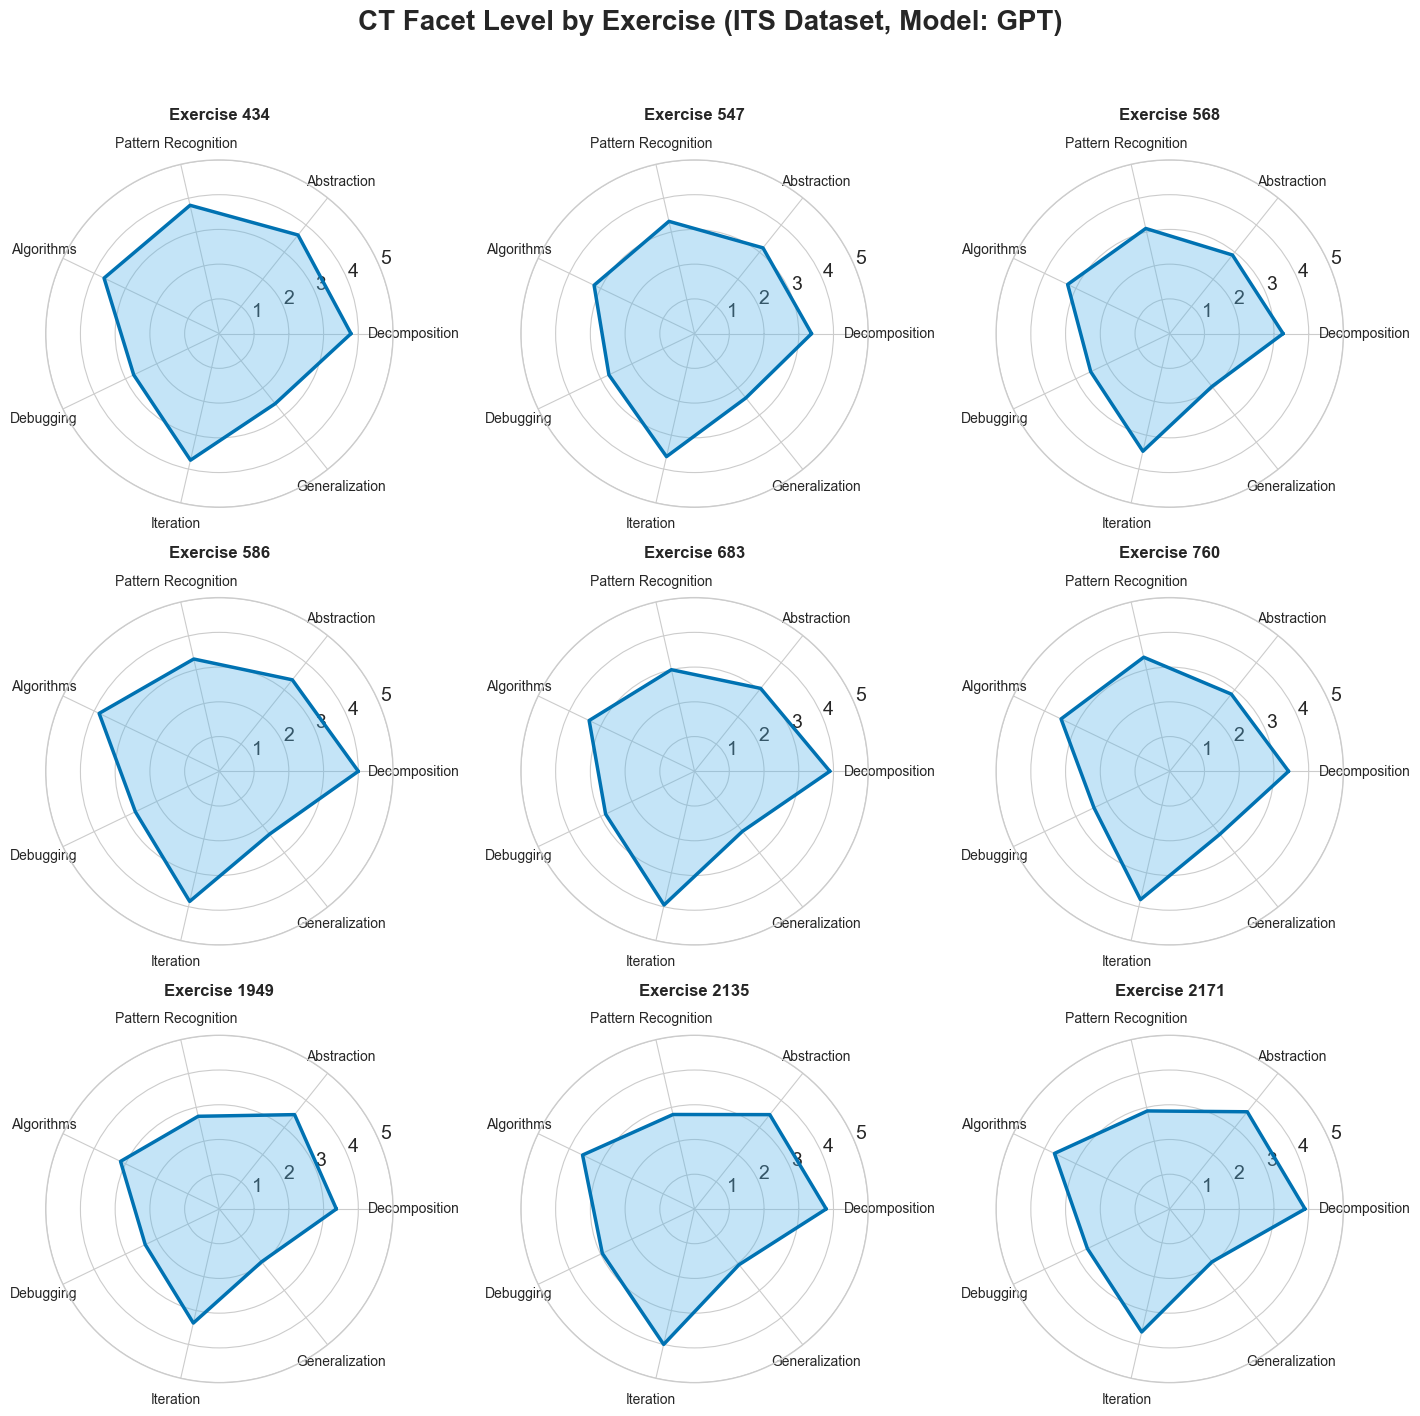

In [ ]:
# CT Score per Exercise (GPT)

import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "CT_levels_all_models.csv"
OUT_PNG = "radar_all_assignments_model_shaded.png"
OUT_PDF = "radar_all_assignments_model_shaded.pdf"

ASSIGNMENT_COL = "AssignmentID"

MODELS = ["GPT", "Llama", "Gemini", "Deepseek"]

FACET_ORDER = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

MODEL_TO_PLOT: Optional[str] = "GPT"   

# Radar scale
R_MIN, R_MAX = 0, 5

DPI = 300
SHOW_FIG = True
SAVE_FIG = True

MODEL_COLORS = {
    "GPT": {
        "line": "#0072B2",   # blue
        "fill": "#56B4E9",   # light blue
    },
    "Llama": {
        "line": "#009E73",   # green
        "fill": "#7FD3B6",   # light green
    },
    "Gemini": {
        "line": "#E69F00",   # orange
        "fill": "#F4C97A",   # light orange
    },
    "Deepseek": {
        "line": "#7B61A3",   # PURPLE (outline)
        "fill": "#D6C7E8",   # LIGHT PURPLE (shade)
    },
    "ALL": {
        "line": "#333333",
        "fill": "#BBBBBB",
    },
}

df = pd.read_csv(INPUT_CSV)

for model in MODELS:
    for facet in FACET_ORDER:
        col = f"{facet}__{model}"
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

def sort_assignments(vals):
    try:
        return sorted(vals, key=lambda x: int(x))
    except Exception:
        return sorted(vals, key=str)

assignments = sort_assignments(df[ASSIGNMENT_COL].dropna().unique())
n_assignments = len(assignments)

def mean_facets_for_assignment(
    df_in: pd.DataFrame,
    assignment_id,
    model: Optional[str]
) -> Optional[np.ndarray]:
    sub = df_in[df_in[ASSIGNMENT_COL].astype(str) == str(assignment_id)]
    if sub.empty:
        return None

    if model is None:
        per_model = []
        for m in MODELS:
            cols = [f"{facet}__{m}" for facet in FACET_ORDER]
            per_model.append(sub[cols].mean(skipna=True).to_numpy())
        return np.nanmean(np.vstack(per_model), axis=0)
    else:
        cols = [f"{facet}__{model}" for facet in FACET_ORDER]
        return sub[cols].mean(skipna=True).to_numpy()

# SUBPLOT LAYOUT
n_cols = int(np.ceil(np.sqrt(n_assignments)))
n_rows = int(np.ceil(n_assignments / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.8 * n_rows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).flatten()

angles = np.linspace(0, 2 * np.pi, len(FACET_ORDER), endpoint=False)
angles_closed = np.r_[angles, angles[0]]

color_key = MODEL_TO_PLOT if MODEL_TO_PLOT is not None else "ALL"
LINE_COLOR = MODEL_COLORS[color_key]["line"]
FILL_COLOR = MODEL_COLORS[color_key]["fill"]

# PLOT
for ax, assignment in zip(axes, assignments):
    vals = mean_facets_for_assignment(df, assignment, MODEL_TO_PLOT)
    if vals is None:
        ax.set_visible(False)
        continue

    vals_closed = np.r_[vals, vals[0]]

    ax.plot(
        angles_closed,
        vals_closed,
        linewidth=2.5,
        color=LINE_COLOR
    )
    ax.fill(
        angles_closed,
        vals_closed,
        color=FILL_COLOR,
        alpha=0.35
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(FACET_ORDER, fontsize=10)
    ax.set_ylim(R_MIN, R_MAX)

    ax.set_title(
        f"Exercise {assignment}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

# Hide unused axes
for ax in axes[len(assignments):]:
    ax.set_visible(False)

model_label = f"Model: {MODEL_TO_PLOT}" if MODEL_TO_PLOT else "Mean across models"
fig.suptitle(
    f"CT Facet Level by Exercise (ITS Dataset, {model_label})",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")

if SHOW_FIG:
    plt.show()

plt.close(fig)


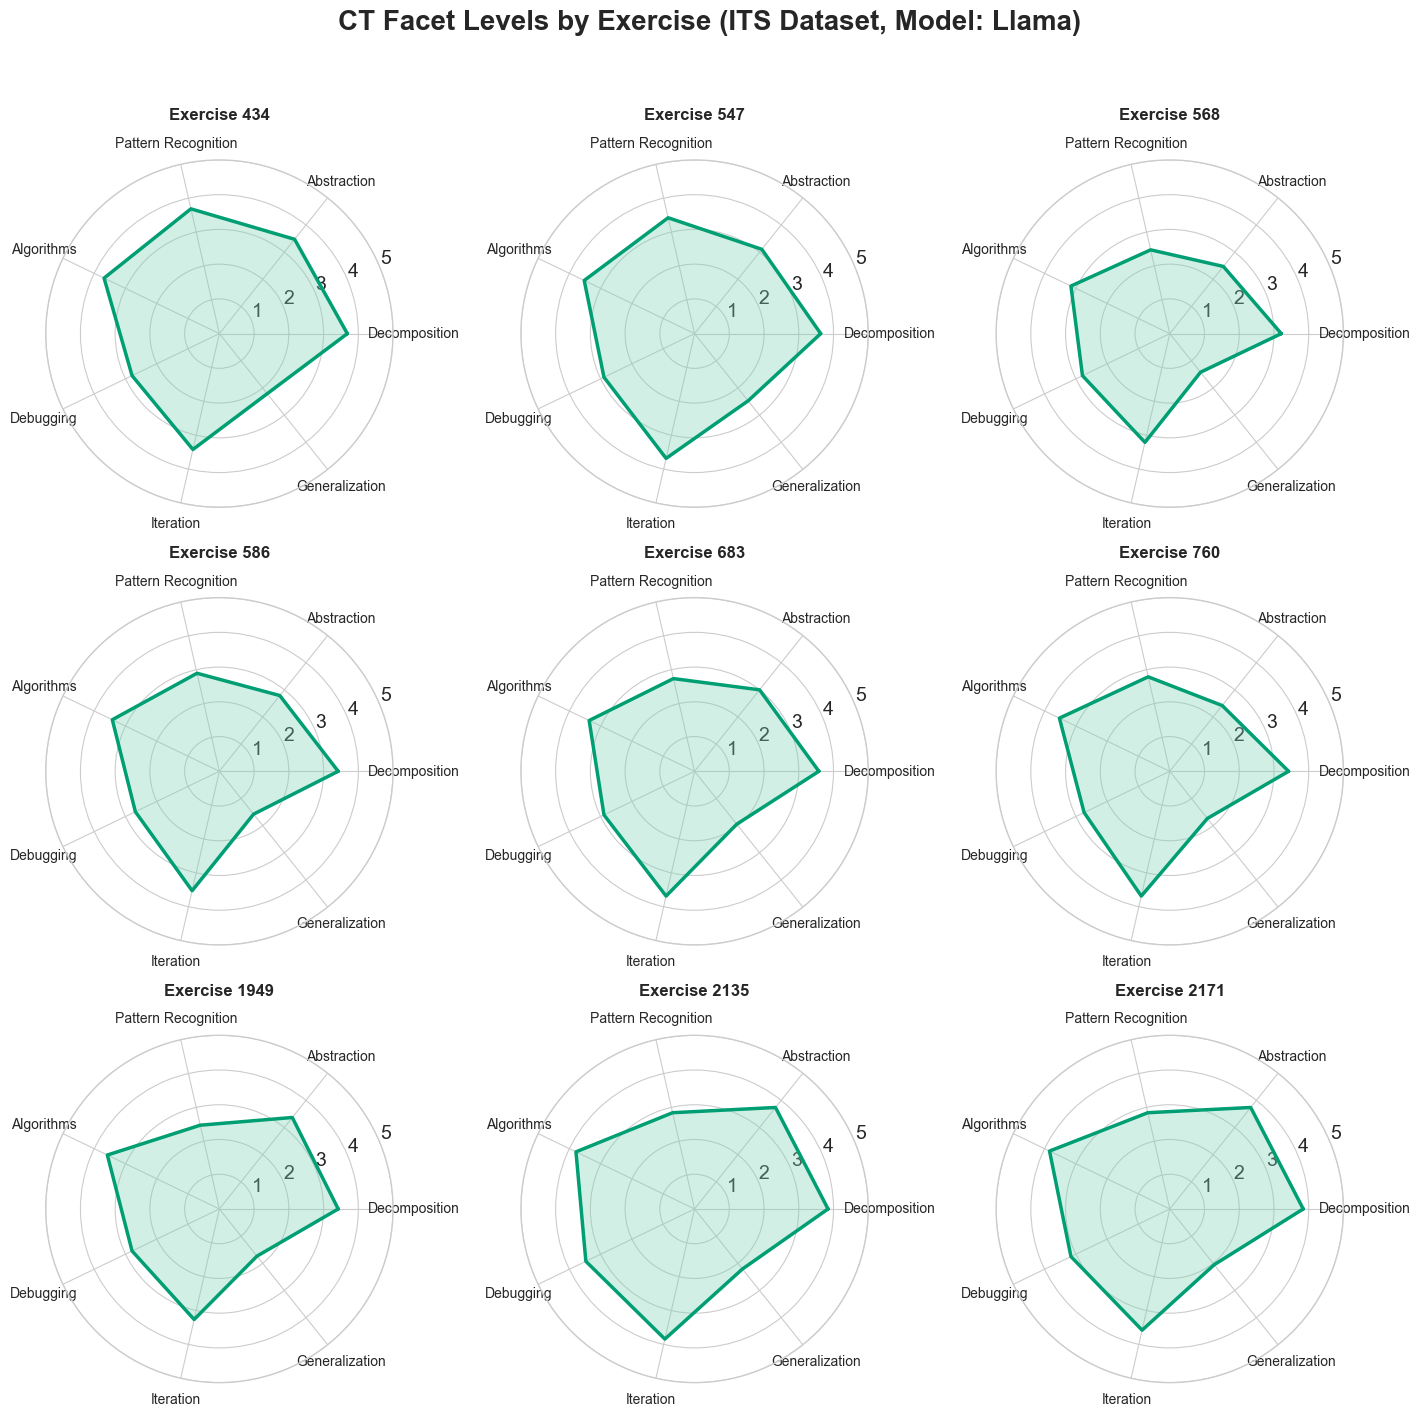

In [ ]:
# CT Score per Exercise (Llama)

import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "CT_levels_all_models.csv"
OUT_PNG = "radar_all_assignments_model_shaded.png"
OUT_PDF = "radar_all_assignments_model_shaded.pdf"

ASSIGNMENT_COL = "AssignmentID"

MODELS = ["GPT", "Llama", "Gemini", "Deepseek"]

FACET_ORDER = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

MODEL_TO_PLOT: Optional[str] = "Llama"  

# Radar scale
R_MIN, R_MAX = 0, 5

DPI = 300
SHOW_FIG = True
SAVE_FIG = True

MODEL_COLORS = {
    "GPT": {
        "line": "#0072B2",   # blue
        "fill": "#56B4E9",   # light blue
    },
    "Llama": {
        "line": "#009E73",   # green
        "fill": "#7FD3B6",   # light green
    },
    "Gemini": {
        "line": "#E69F00",   # orange
        "fill": "#F4C97A",   # light orange
    },
    "Deepseek": {
        "line": "#7B61A3",   # PURPLE (outline)
        "fill": "#D6C7E8",   # LIGHT PURPLE (shade)
    },
    "ALL": {
        "line": "#333333",
        "fill": "#BBBBBB",
    },
}

df = pd.read_csv(INPUT_CSV)

for model in MODELS:
    for facet in FACET_ORDER:
        col = f"{facet}__{model}"
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

def sort_assignments(vals):
    try:
        return sorted(vals, key=lambda x: int(x))
    except Exception:
        return sorted(vals, key=str)

assignments = sort_assignments(df[ASSIGNMENT_COL].dropna().unique())
n_assignments = len(assignments)

def mean_facets_for_assignment(
    df_in: pd.DataFrame,
    assignment_id,
    model: Optional[str]
) -> Optional[np.ndarray]:
    sub = df_in[df_in[ASSIGNMENT_COL].astype(str) == str(assignment_id)]
    if sub.empty:
        return None

    if model is None:
        per_model = []
        for m in MODELS:
            cols = [f"{facet}__{m}" for facet in FACET_ORDER]
            per_model.append(sub[cols].mean(skipna=True).to_numpy())
        return np.nanmean(np.vstack(per_model), axis=0)
    else:
        cols = [f"{facet}__{model}" for facet in FACET_ORDER]
        return sub[cols].mean(skipna=True).to_numpy()

# SUBPLOT LAYOUT
n_cols = int(np.ceil(np.sqrt(n_assignments)))
n_rows = int(np.ceil(n_assignments / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.8 * n_rows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).flatten()

angles = np.linspace(0, 2 * np.pi, len(FACET_ORDER), endpoint=False)
angles_closed = np.r_[angles, angles[0]]

color_key = MODEL_TO_PLOT if MODEL_TO_PLOT is not None else "ALL"
LINE_COLOR = MODEL_COLORS[color_key]["line"]
FILL_COLOR = MODEL_COLORS[color_key]["fill"]

# PLOT
for ax, assignment in zip(axes, assignments):
    vals = mean_facets_for_assignment(df, assignment, MODEL_TO_PLOT)
    if vals is None:
        ax.set_visible(False)
        continue

    vals_closed = np.r_[vals, vals[0]]

    ax.plot(
        angles_closed,
        vals_closed,
        linewidth=2.5,
        color=LINE_COLOR
    )
    ax.fill(
        angles_closed,
        vals_closed,
        color=FILL_COLOR,
        alpha=0.35
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(FACET_ORDER, fontsize=10)
    ax.set_ylim(R_MIN, R_MAX)

    ax.set_title(
        f"Exercise {assignment}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

for ax in axes[len(assignments):]:
    ax.set_visible(False)

model_label = f"Model: {MODEL_TO_PLOT}" if MODEL_TO_PLOT else "Mean across models"
fig.suptitle(
    f"CT Facet Levels by Exercise (ITS Dataset, {model_label})",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")

if SHOW_FIG:
    plt.show()

plt.close(fig)


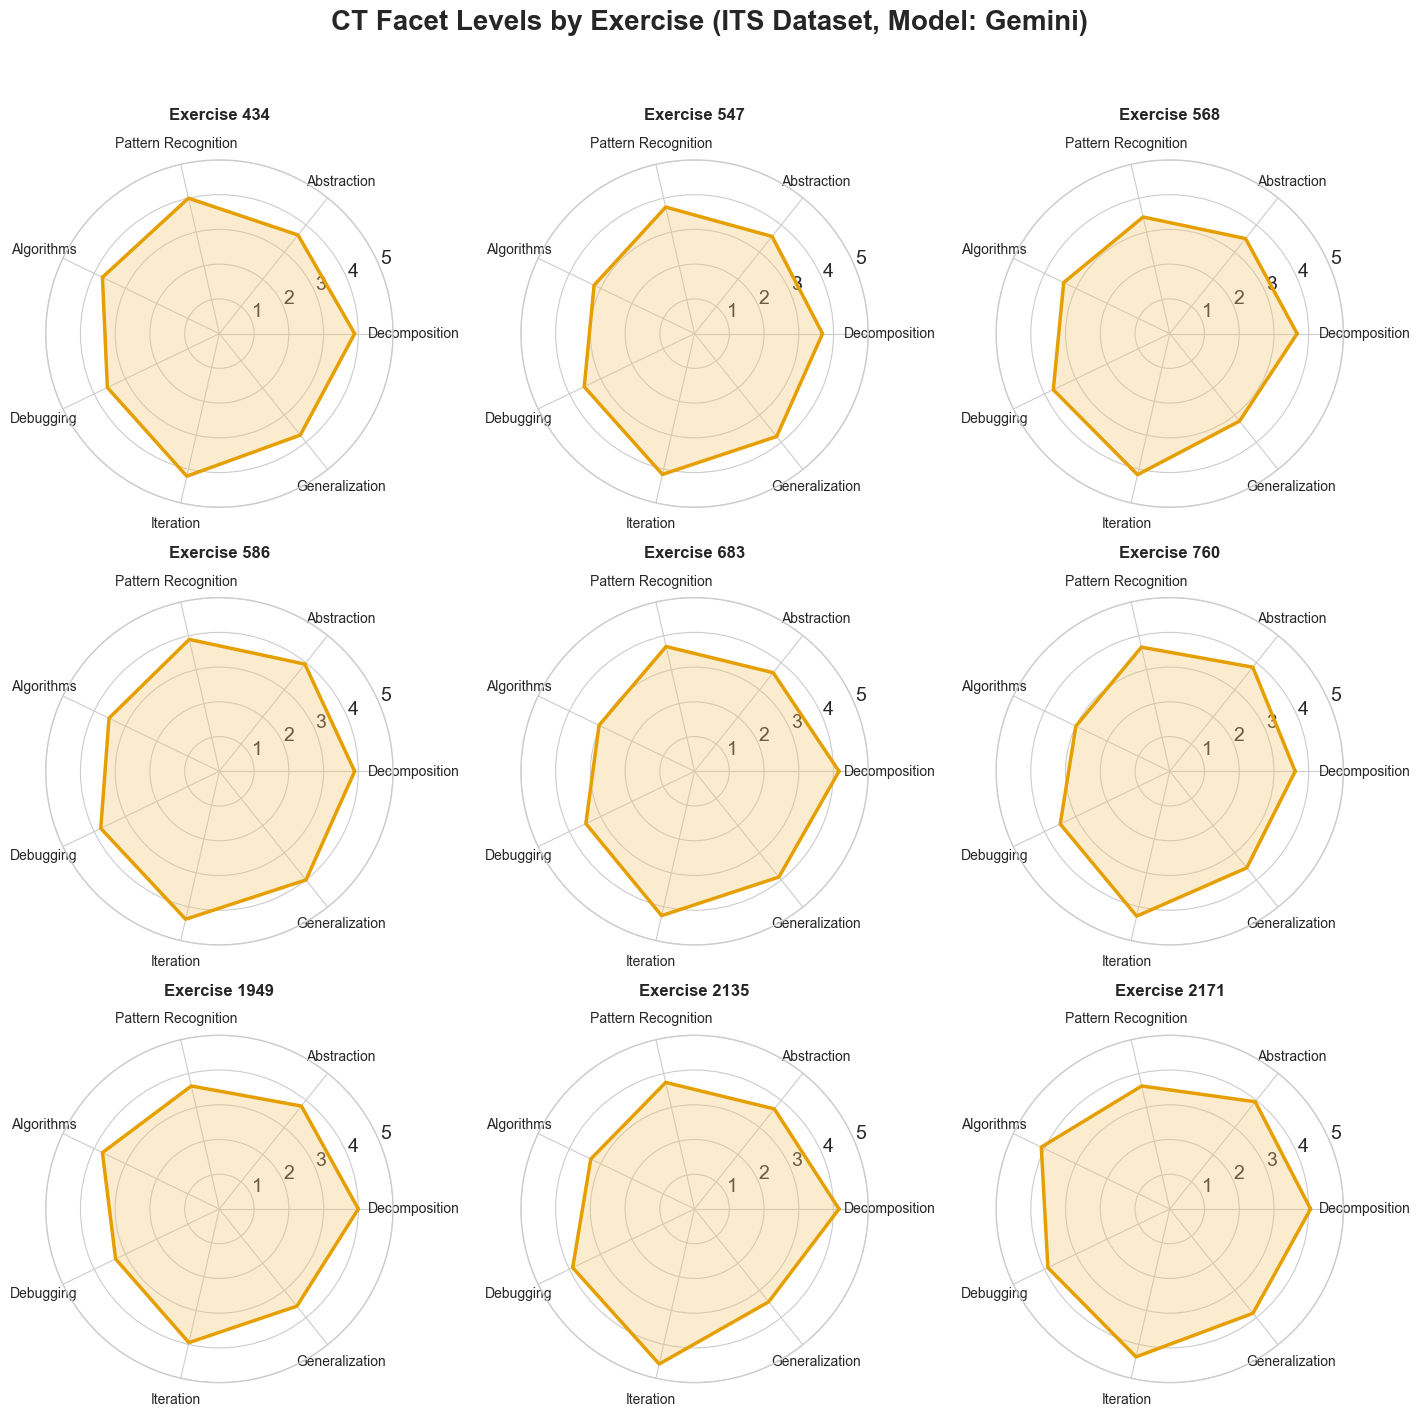

In [ ]:
# CT Score per Exercise (Gemini)

import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "CT_levels_all_models.csv"
OUT_PNG = "radar_all_assignments_model_shaded.png"
OUT_PDF = "radar_all_assignments_model_shaded.pdf"

ASSIGNMENT_COL = "AssignmentID"

MODELS = ["GPT", "Llama", "Gemini", "Deepseek"]

FACET_ORDER = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

MODEL_TO_PLOT: Optional[str] = "Gemini"  

# Radar scale
R_MIN, R_MAX = 0, 5

DPI = 300
SHOW_FIG = True
SAVE_FIG = True

MODEL_COLORS = {
    "GPT": {
        "line": "#0072B2",   # blue
        "fill": "#56B4E9",   # light blue
    },
    "Llama": {
        "line": "#009E73",   # green
        "fill": "#7FD3B6",   # light green
    },
    "Gemini": {
        "line": "#E69F00",   # orange
        "fill": "#F4C97A",   # light orange
    },
    "Deepseek": {
        "line": "#7B61A3",   # PURPLE (outline)
        "fill": "#D6C7E8",   # LIGHT PURPLE (shade)
    },
    "ALL": {
        "line": "#333333",
        "fill": "#BBBBBB",
    },
}

# =========================
# LOAD
# =========================
df = pd.read_csv(INPUT_CSV)

# Ensure numeric CT scores
for model in MODELS:
    for facet in FACET_ORDER:
        col = f"{facet}__{model}"
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort assignments nicely
def sort_assignments(vals):
    try:
        return sorted(vals, key=lambda x: int(x))
    except Exception:
        return sorted(vals, key=str)

assignments = sort_assignments(df[ASSIGNMENT_COL].dropna().unique())
n_assignments = len(assignments)

def mean_facets_for_assignment(
    df_in: pd.DataFrame,
    assignment_id,
    model: Optional[str]
) -> Optional[np.ndarray]:
    sub = df_in[df_in[ASSIGNMENT_COL].astype(str) == str(assignment_id)]
    if sub.empty:
        return None

    if model is None:
        per_model = []
        for m in MODELS:
            cols = [f"{facet}__{m}" for facet in FACET_ORDER]
            per_model.append(sub[cols].mean(skipna=True).to_numpy())
        return np.nanmean(np.vstack(per_model), axis=0)
    else:
        cols = [f"{facet}__{model}" for facet in FACET_ORDER]
        return sub[cols].mean(skipna=True).to_numpy()

# SUBPLOT LAYOUT
n_cols = int(np.ceil(np.sqrt(n_assignments)))
n_rows = int(np.ceil(n_assignments / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.8 * n_rows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).flatten()

angles = np.linspace(0, 2 * np.pi, len(FACET_ORDER), endpoint=False)
angles_closed = np.r_[angles, angles[0]]

color_key = MODEL_TO_PLOT if MODEL_TO_PLOT is not None else "ALL"
LINE_COLOR = MODEL_COLORS[color_key]["line"]
FILL_COLOR = MODEL_COLORS[color_key]["fill"]

# PLOT
for ax, assignment in zip(axes, assignments):
    vals = mean_facets_for_assignment(df, assignment, MODEL_TO_PLOT)
    if vals is None:
        ax.set_visible(False)
        continue

    vals_closed = np.r_[vals, vals[0]]

    ax.plot(
        angles_closed,
        vals_closed,
        linewidth=2.5,
        color=LINE_COLOR
    )
    ax.fill(
        angles_closed,
        vals_closed,
        color=FILL_COLOR,
        alpha=0.35
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(FACET_ORDER, fontsize=10)
    ax.set_ylim(R_MIN, R_MAX)

    ax.set_title(
        f"Exercise {assignment}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

for ax in axes[len(assignments):]:
    ax.set_visible(False)

model_label = f"Model: {MODEL_TO_PLOT}" if MODEL_TO_PLOT else "Mean across models"
fig.suptitle(
    f"CT Facet Levels by Exercise (ITS Dataset, {model_label})",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")

if SHOW_FIG:
    plt.show()

plt.close(fig)


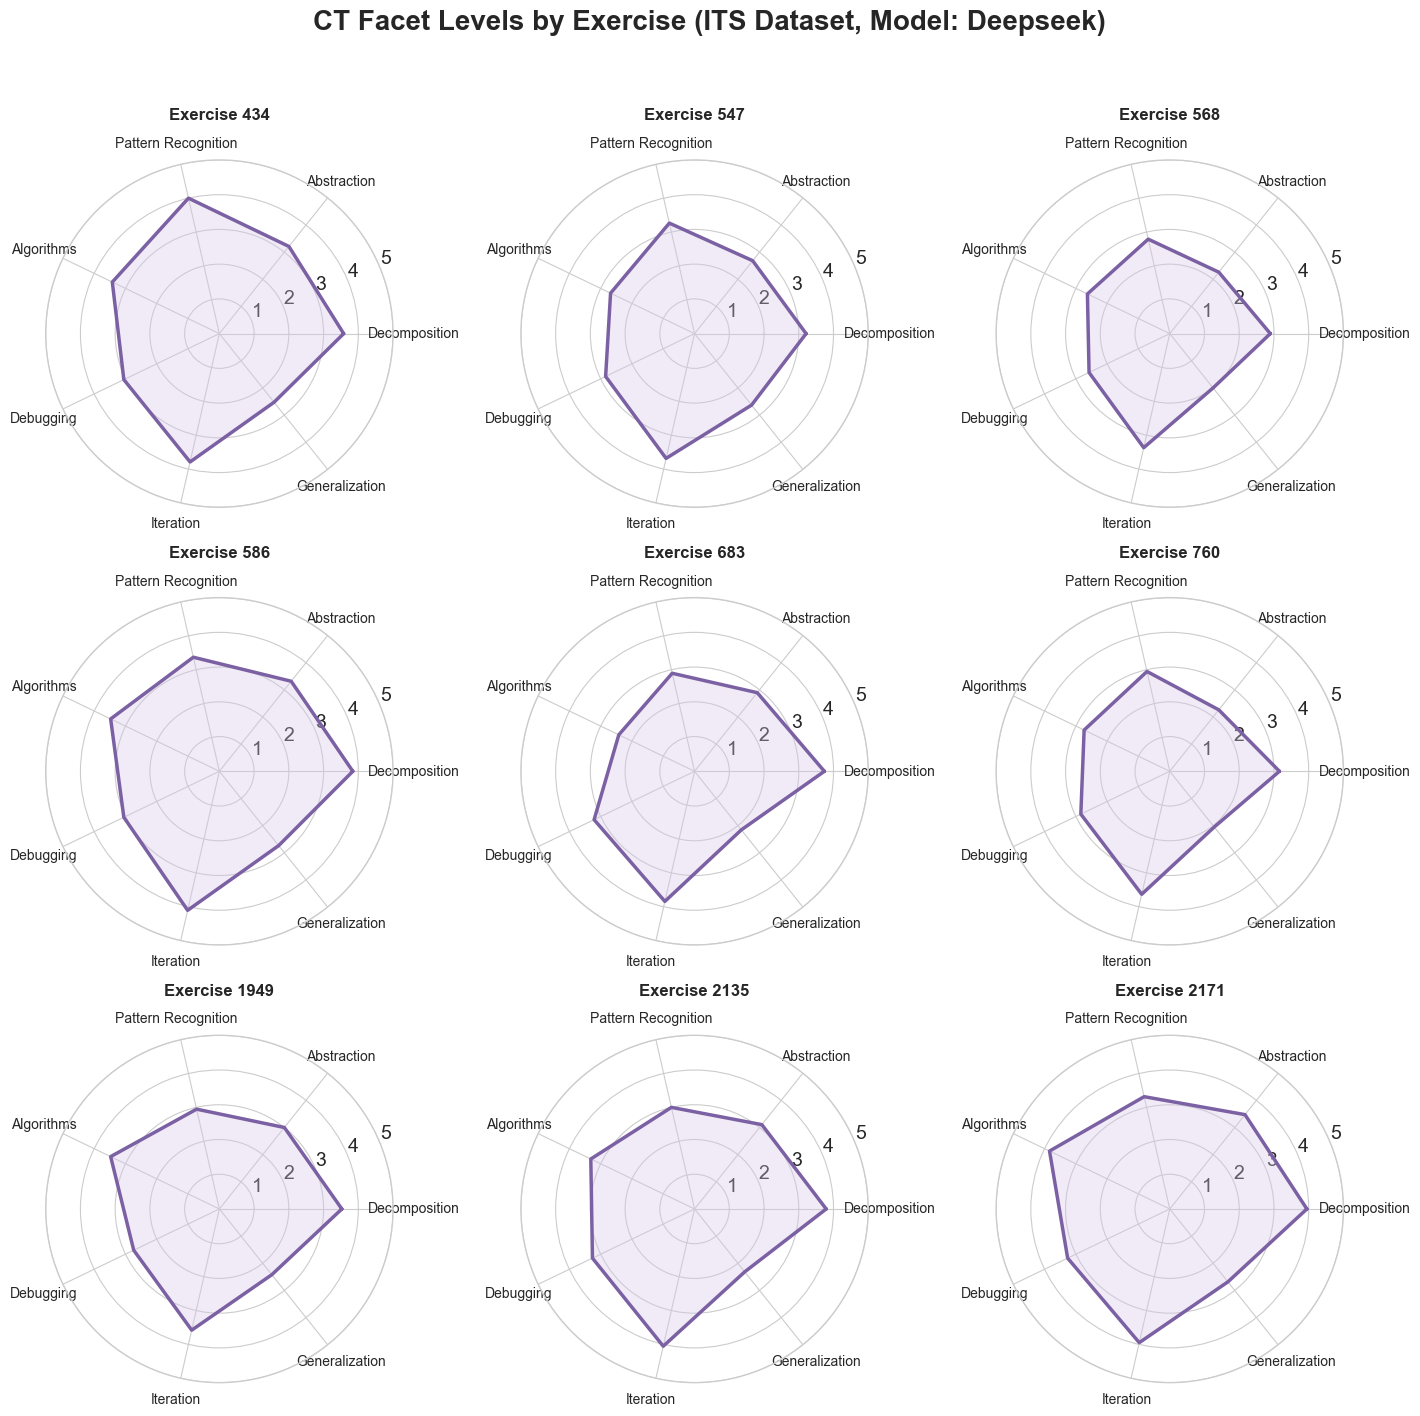

In [ ]:
# CT Score per Exercise (Deepseek)

import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "CT_levels_all_models.csv"
OUT_PNG = "radar_all_assignments_model_shaded.png"
OUT_PDF = "radar_all_assignments_model_shaded.pdf"

ASSIGNMENT_COL = "AssignmentID"

MODELS = ["GPT", "Llama", "Gemini", "Deepseek"]

FACET_ORDER = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

MODEL_TO_PLOT: Optional[str] = "Deepseek"   

# Radar scale
R_MIN, R_MAX = 0, 5

DPI = 300
SHOW_FIG = True
SAVE_FIG = True


MODEL_COLORS = {
    "GPT": {
        "line": "#0072B2",   # blue
        "fill": "#56B4E9",   # light blue
    },
    "Llama": {
        "line": "#009E73",   # green
        "fill": "#7FD3B6",   # light green
    },
    "Gemini": {
        "line": "#E69F00",   # orange
        "fill": "#F4C97A",   # light orange
    },
    "Deepseek": {
        "line": "#7B61A3",   # PURPLE (outline)
        "fill": "#D6C7E8",   # LIGHT PURPLE (shade)
    },
    "ALL": {
        "line": "#333333",
        "fill": "#BBBBBB",
    },
}

# MODEL_COLORS = {
#     "GPT": {
#         "line": "#0072B2",   # blue
#         "fill": "#56B4E9",   # light blue
#     },
#     "Llama": {
#         "line": "#009E73",   # green
#         "fill": "#7FD3B6",   # light green
#     },
#     "Gemini": {
#         "line": "#E69F00",   # orange
#         "fill": "#F4C97A",   # light orange
#     },
#     "Deepseek": {
#         "line": "#C44E52",   # muted red (Okabe–Ito)
#         "fill": "#F2B6B6",   # light red / pinkish
#     },
#     "ALL": {
#         "line": "#333333",
#         "fill": "#BBBBBB",
#     },
# }

df = pd.read_csv(INPUT_CSV)

for model in MODELS:
    for facet in FACET_ORDER:
        col = f"{facet}__{model}"
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

def sort_assignments(vals):
    try:
        return sorted(vals, key=lambda x: int(x))
    except Exception:
        return sorted(vals, key=str)

assignments = sort_assignments(df[ASSIGNMENT_COL].dropna().unique())
n_assignments = len(assignments)

def mean_facets_for_assignment(
    df_in: pd.DataFrame,
    assignment_id,
    model: Optional[str]
) -> Optional[np.ndarray]:
    sub = df_in[df_in[ASSIGNMENT_COL].astype(str) == str(assignment_id)]
    if sub.empty:
        return None

    if model is None:
        per_model = []
        for m in MODELS:
            cols = [f"{facet}__{m}" for facet in FACET_ORDER]
            per_model.append(sub[cols].mean(skipna=True).to_numpy())
        return np.nanmean(np.vstack(per_model), axis=0)
    else:
        cols = [f"{facet}__{model}" for facet in FACET_ORDER]
        return sub[cols].mean(skipna=True).to_numpy()

# SUBPLOT LAYOUT
n_cols = int(np.ceil(np.sqrt(n_assignments)))
n_rows = int(np.ceil(n_assignments / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.8 * n_rows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).flatten()

angles = np.linspace(0, 2 * np.pi, len(FACET_ORDER), endpoint=False)
angles_closed = np.r_[angles, angles[0]]

color_key = MODEL_TO_PLOT if MODEL_TO_PLOT is not None else "ALL"
LINE_COLOR = MODEL_COLORS[color_key]["line"]
FILL_COLOR = MODEL_COLORS[color_key]["fill"]

# PLOT
for ax, assignment in zip(axes, assignments):
    vals = mean_facets_for_assignment(df, assignment, MODEL_TO_PLOT)
    if vals is None:
        ax.set_visible(False)
        continue

    vals_closed = np.r_[vals, vals[0]]

    ax.plot(
        angles_closed,
        vals_closed,
        linewidth=2.5,
        color=LINE_COLOR
    )
    ax.fill(
        angles_closed,
        vals_closed,
        color=FILL_COLOR,
        alpha=0.35
    )

    ax.set_xticks(angles)
    ax.set_xticklabels(FACET_ORDER, fontsize=10)
    ax.set_ylim(R_MIN, R_MAX)

    ax.set_title(
        f"Exercise {assignment}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

for ax in axes[len(assignments):]:
    ax.set_visible(False)

model_label = f"Model: {MODEL_TO_PLOT}" if MODEL_TO_PLOT else "Mean across models"
fig.suptitle(
    f"CT Facet Levels by Exercise (ITS Dataset, {model_label})",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_FIG:
    fig.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")

if SHOW_FIG:
    plt.show()

plt.close(fig)


### Check mean judgement

In [ ]:
from __future__ import annotations
import os
from pathlib import Path
import pandas as pd

JUDGE_FILES = {
    "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}


# Output folder
OUT_DIR = "mean_agreement_outputs"

# Columns
COL_STUDENT = "student_id"
COL_EXERCISE = "exercise_id"
COL_JUDGE = "judge_model_anon"
COL_EVALUATED = "evaluated_model_anon"
COL_FACET = "facet"
COL_SCORE = "Judgement_score"
COL_EXPL = "Judgement_explanation"  


def load_and_stack_csvs(files: list[str]) -> pd.DataFrame:
    dfs = []
    for fp in files:
        if not Path(fp).exists():
            raise FileNotFoundError(f"Missing file: {fp}")

        df = pd.read_csv(fp)

        required = [COL_STUDENT, COL_EXERCISE, COL_JUDGE, COL_EVALUATED, COL_SCORE]
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(
                f"File '{fp}' is missing required columns: {missing}\n"
                f"Found columns: {list(df.columns)}"
            )

        df = df.copy()

        df[COL_JUDGE] = df[COL_JUDGE].astype(str).str.strip()
        df[COL_EVALUATED] = df[COL_EVALUATED].astype(str).str.strip()
        df[COL_SCORE] = pd.to_numeric(df[COL_SCORE], errors="coerce")

        df = df.dropna(subset=[COL_JUDGE, COL_EVALUATED, COL_SCORE])

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

all_judgments = load_and_stack_csvs(JUDGE_FILES)

clean = all_judgments[all_judgments[COL_JUDGE] != all_judgments[COL_EVALUATED]].copy()


# MEAN AGREEMENT AS EVALUATEE
mean_agreement_overall = (
    clean.groupby(COL_EVALUATED)[COL_SCORE]
         .agg(
             mean_agreement="mean",
             std_agreement="std",
             n_rows="count"
         )
         .reset_index()
         .sort_values("mean_agreement", ascending=False)
)

# JUDGE-BALANCED MEAN
per_judge_means = (
    clean.groupby([COL_EVALUATED, COL_JUDGE])[COL_SCORE]
         .mean()
         .reset_index(name="judge_mean_score")
)

mean_agreement_judge_balanced = (
    per_judge_means.groupby(COL_EVALUATED)["judge_mean_score"]
                  .agg(
                      mean_agreement="mean",
                      std_across_judges="std",
                      n_judges="count"
                  )
                  .reset_index()
                  .sort_values("mean_agreement", ascending=False)
)

# MIN AGREEMENT ACROSS JUDGES
min_agreement_across_judges = (
    per_judge_means.groupby(COL_EVALUATED)["judge_mean_score"]
                  .min()
                  .reset_index(name="min_judge_mean_score")
                  .sort_values("min_judge_mean_score", ascending=False)
)

# FACET LEVEL OUTPUTS
facet_means = None
facet_means_judge_balanced = None

if COL_FACET in clean.columns:
    facet_means = (
        clean.groupby([COL_EVALUATED, COL_FACET])[COL_SCORE]
             .mean()
             .reset_index()
             .pivot(index=COL_EVALUATED, columns=COL_FACET, values=COL_SCORE)
    )

    per_judge_facet = (
        clean.groupby([COL_EVALUATED, COL_JUDGE, COL_FACET])[COL_SCORE]
             .mean()
             .reset_index(name="judge_facet_mean")
    )

    facet_means_judge_balanced = (
        per_judge_facet.groupby([COL_EVALUATED, COL_FACET])["judge_facet_mean"]
                      .mean()
                      .reset_index()
                      .pivot(index=COL_EVALUATED, columns=COL_FACET, values="judge_facet_mean")
    )

judge_counts = (
    clean.groupby(COL_EVALUATED)[COL_JUDGE]
         .nunique()
         .reset_index(name="n_unique_judges")
         .sort_values("n_unique_judges")
)

judge_describe = (
    clean.groupby(COL_JUDGE)[COL_SCORE]
         .describe()
         .reset_index()
)

coverage = None
if COL_FACET in clean.columns:
    coverage = (
        clean.groupby([COL_EVALUATED, COL_FACET])[COL_JUDGE]
             .nunique()
             .reset_index(name="n_unique_judges_for_facet")
             .sort_values(["n_unique_judges_for_facet", COL_EVALUATED, COL_FACET])
    )

os.makedirs(OUT_DIR, exist_ok=True)

mean_agreement_overall.to_csv(Path(OUT_DIR) / "mean_agreement_overall.csv", index=False)
mean_agreement_judge_balanced.to_csv(Path(OUT_DIR) / "mean_agreement_judge_balanced.csv", index=False)
min_agreement_across_judges.to_csv(Path(OUT_DIR) / "min_agreement_across_judges.csv", index=False)
judge_counts.to_csv(Path(OUT_DIR) / "sanity_judge_counts_per_evaluatee.csv", index=False)
judge_describe.to_csv(Path(OUT_DIR) / "sanity_judge_score_describe.csv", index=False)

if facet_means is not None:
    facet_means.to_csv(Path(OUT_DIR) / "facet_mean_agreement.csv")
if facet_means_judge_balanced is not None:
    facet_means_judge_balanced.to_csv(Path(OUT_DIR) / "facet_mean_agreement_judge_balanced.csv")
if coverage is not None:
    coverage.to_csv(Path(OUT_DIR) / "sanity_coverage_judges_by_facet.csv", index=False)


pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)

print("\n==============================")
print("Mean agreement as evaluatee")
print("==============================")
print(mean_agreement_overall)

print("\n==============================")
print("Mean agreement as evaluatee (judge-balanced)")
print("==============================")
print(mean_agreement_judge_balanced)

print("\n==============================")
print("minimum judge-mean score (per evaluatee)")
print("==============================")
print(min_agreement_across_judges)

# print("\n==============================")
# print(" # unique judges per evaluated model")
# print("==============================")
# print(judge_counts)

# print("\n==============================")
# print("judge score distributions")
# print("==============================")
# print(judge_describe)

if facet_means is not None:
    print("\n==============================")
    print("Facet-level mean agreement (plain)")
    print("==============================")
    print(facet_means)

if facet_means_judge_balanced is not None:
    print("\n==============================")
    print("Facet-level mean agreement (judge-balanced)")
    print("==============================")
    print(facet_means_judge_balanced)

# if coverage is not None:
#     print("\n==============================")
#     print("# unique judges per (evaluatee, facet)")
#     print("==============================")
#     print(coverage.head(30))

print(f"\n Done. Wrote outputs to: {OUT_DIR}/")



Mean agreement as evaluatee (overall)
  evaluated_model_anon  mean_agreement  std_agreement  n_rows
2              Model C        4.159482       0.779481    3549
3              Model D        3.893901       0.842231    3591
0              Model A        3.706128       0.840757    3590
1              Model B        3.697493       0.839847    3590

Mean agreement as evaluatee (judge-balanced)  [RECOMMENDED]
  evaluated_model_anon  mean_agreement  std_across_judges  n_judges
2              Model C        4.159482           0.168249         3
3              Model D        3.893901           0.064620         3
0              Model A        3.706126           0.262379         3
1              Model B        3.697477           0.087244         3

Robustness: minimum judge-mean score (per evaluatee)
  evaluated_model_anon  min_judge_mean_score
2              Model C              3.966188
3              Model D              3.819549
1              Model B              3.639632
0              M

[OK] Wrote matrix CSV: ./pairwise_judging_files/matrices/pairwise_matrix_ALL_students_ALL_exercises_ALL_facets.csv


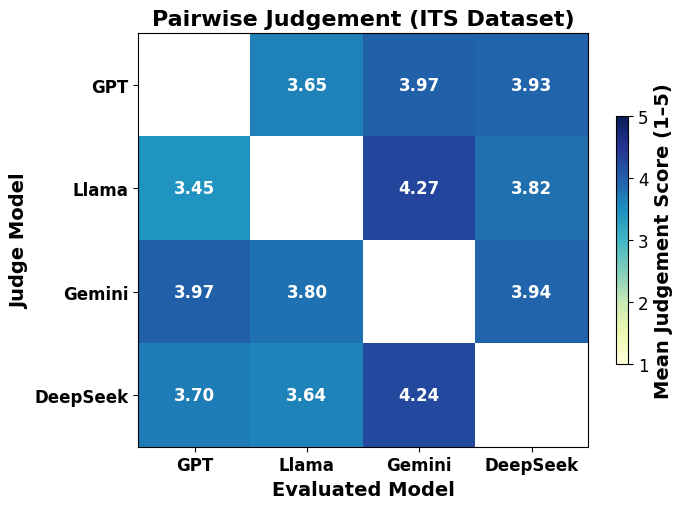

[OK] Wrote heatmap PNG: ./pairwise_judging_files/matrices/pairwise_matrix_ALL_students_ALL_exercises_ALL_facets.png


In [ ]:
# NON anonymized (display labels)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices/"
os.makedirs(OUT_FOLDER, exist_ok=True)

STUDENTS = None
ASSIGNMENTS = None

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

ORDER = ["Model A", "Model B", "Model C", "Model D"]

USE_DISPLAY_LABELS = True
DISPLAY_LABELS = {
    "Model A": "GPT",
    "Model B": "Llama",
    "Model C": "Gemini",
    "Model D": "DeepSeek",
}

MAKE_HEATMAP = True
VMIN, VMAX = 1, 5
COLORBAR_SHRINK = 0.6

HEATMAP_CMAP_NAME = "YlGnBu"
NAN_COLOR = "white"

TITLE_SIZE = 16
AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
COLORBAR_LABEL_SIZE = 14
COLORBAR_TICK_SIZE = 12
CELL_TEXT_SIZE = 12

FIGSIZE = (7.2, 5.2)   
DPI = 300

plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
})

def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df = df[list(req)].copy()
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")

        df["student_id"] = df["student_id"].astype(str)
        df["exercise_id"] = df["exercise_id"].astype(str)

        parts.append(df)

    all_df = pd.concat(parts, ignore_index=True)

    all_df = all_df.dropna(subset=["Judgement_score"]).copy()
    return all_df


DETAILS_DF = load_all_details()

# BUILD ONE MATRIX (ALL STUDENTS/EXERCISES/FACETS)
def build_matrix_all(students=None, assignments=None):
    sub = DETAILS_DF.copy()

    if students is not None:
        sub = sub[sub["student_id"].isin([str(s) for s in students])]
    if assignments is not None:
        sub = sub[sub["exercise_id"].isin([str(a) for a in assignments])]

    if sub.empty:
        return None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
           .mean()
           .reset_index()
    )

    mat = (
        agg.pivot(index="judge_model_anon", columns="evaluated_model_anon", values="Judgement_score")
           .reindex(index=ORDER, columns=ORDER)
    )

    # diagonal empty
    for m in ORDER:
        mat.loc[m, m] = np.nan

    return mat

# HEATMAP
def draw_heatmap(mat: pd.DataFrame, title: str, out_png: str):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    cmap = plt.get_cmap(HEATMAP_CMAP_NAME).copy()
    cmap.set_bad(color=NAN_COLOR)

    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, cmap=cmap, aspect="auto")

    xlabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER
    ylabels = [DISPLAY_LABELS[m] for m in ORDER] if USE_DISPLAY_LABELS else ORDER

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))
    ax.set_xticklabels(xlabels, ha="center", fontsize=TICK_LABEL_SIZE, fontweight="bold")
    ax.set_yticklabels(ylabels, fontsize=TICK_LABEL_SIZE, fontweight="bold")

    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_xlabel("Evaluated Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("Judge Model", fontsize=AXIS_LABEL_SIZE, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
    cbar.set_label("Mean Judgement Score (1–5)", fontsize=COLORBAR_LABEL_SIZE, fontweight="bold")
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)

    norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color=text_color,
                    fontsize=CELL_TEXT_SIZE,
                    fontweight="bold"
                )

    ax.grid(False)
    ax.minorticks_off()

    plt.tight_layout()
    plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)

mat = build_matrix_all(students=STUDENTS, assignments=ASSIGNMENTS)
if mat is None:
    raise ValueError("No rows found after filtering (or dataset is empty).")

out_csv = os.path.join(OUT_FOLDER, "pairwise_matrix_ALL_students_ALL_exercises_ALL_facets.csv")
mat.to_csv(out_csv, index=True)
print(f"[OK] Wrote matrix CSV: {out_csv}")

if MAKE_HEATMAP:
    out_png = os.path.join(OUT_FOLDER, "pairwise_matrix_ALL_students_ALL_exercises_ALL_facets.png")
    draw_heatmap(mat, title="Pairwise Judgement (ITS Dataset)", out_png=out_png)
    print(f"[OK] Wrote heatmap PNG: {out_png}")


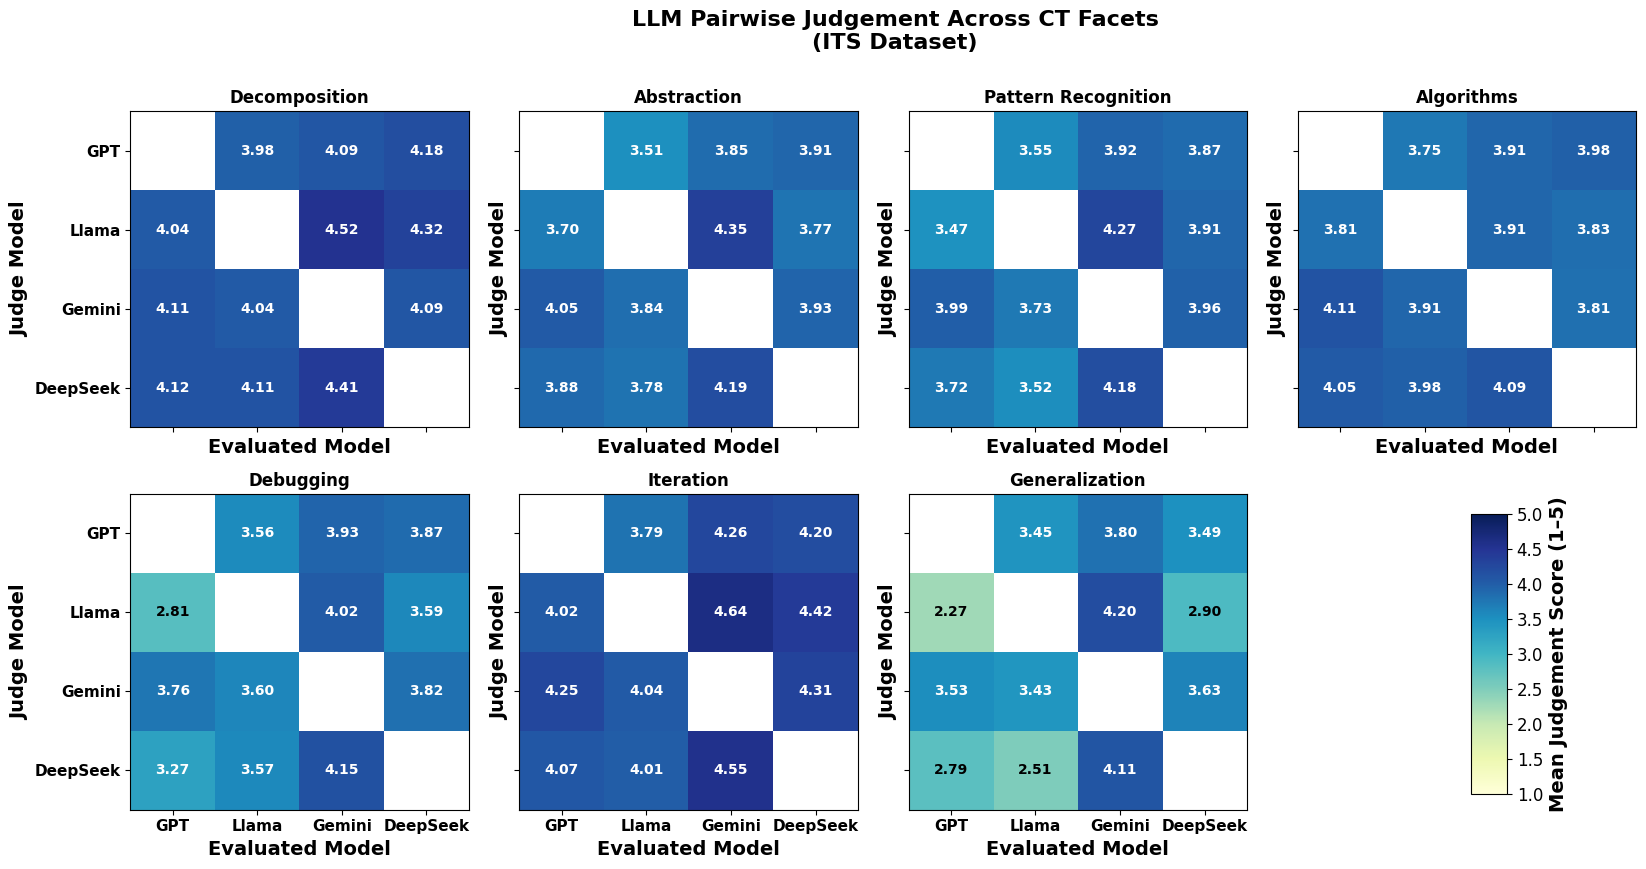

[OK] Saved combined facet figure: ./pairwise_judging_files/matrices/pairwise_judgement_ALL_facets_ONE_figure.png


In [ ]:

# LLM pairwise judgement heatmaps
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DETAILS_FOLDER = "./pairwise_judging_files/"
OUT_FOLDER = "./pairwise_judging_files/matrices/"
os.makedirs(OUT_FOLDER, exist_ok=True)

DETAIL_FILES = {
    "GPT": "GPT_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Llama": "Llama_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "Gemini": "Gemini_blind_pairwise_judgment_anonymized_ALL_details.csv",
    "DeepSeek": "DeepSeek_blind_pairwise_judgment_anonymized_ALL_details.csv",
}

STUDENTS = None
ASSIGNMENTS = None

FACET_ORDER = [
    "Decomposition",
    "Abstraction",
    "Pattern Recognition",
    "Algorithms",
    "Debugging",
    "Iteration",
    "Generalization",
]

ORDER = ["Model A", "Model B", "Model C", "Model D"]

DISPLAY_LABELS = {
    "Model A": "GPT",
    "Model B": "Llama",
    "Model C": "Gemini",
    "Model D": "DeepSeek",
}

VMIN, VMAX = 1, 5
HEATMAP_CMAP_NAME = "YlGnBu"
NAN_COLOR = "white"

FIGSIZE = (16, 8)      
DPI = 300

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
TICK_LABEL_SIZE = 11
CELL_TEXT_SIZE = 10

CBAR_AX = [0.90, 0.20, 0.015, 0.60]  
TIGHT_RECT = [0, 0, 0.88, 1]        


def load_all_details():
    parts = []
    for judge_name, fn in DETAIL_FILES.items():
        path = os.path.join(DETAILS_FOLDER, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path)

        req = {
            "student_id",
            "exercise_id",
            "judge_model_anon",
            "evaluated_model_anon",
            "facet",
            "Judgement_score",
        }
        missing = req - set(df.columns)
        if missing:
            raise ValueError(f"{fn} missing columns: {missing}")

        df = df[list(req)].copy()
        df["Judgement_score"] = pd.to_numeric(df["Judgement_score"], errors="coerce")
        df = df.dropna(subset=["Judgement_score"]).copy()

        df["student_id"] = df["student_id"].astype(str)
        df["exercise_id"] = df["exercise_id"].astype(str)
        df["facet"] = df["facet"].astype(str)

        parts.append(df)

    return pd.concat(parts, ignore_index=True)

DETAILS_DF = load_all_details()

# BUILD MATRIX ACROSS ALL STUDENTS/ASSIGNMENTS, OPTIONAL PER FACET
def build_matrix_all(students=None, assignments=None, facet=None):
    sub = DETAILS_DF

    if students is not None:
        sub = sub[sub["student_id"].isin([str(s) for s in students])]
    if assignments is not None:
        sub = sub[sub["exercise_id"].isin([str(a) for a in assignments])]
    if facet is not None:
        sub = sub[sub["facet"] == facet]

    if sub.empty:
        return None

    agg = (
        sub.groupby(["judge_model_anon", "evaluated_model_anon"], dropna=False)["Judgement_score"]
          .mean()
          .reset_index()
    )

    mat = (
        agg.pivot(index="judge_model_anon", columns="evaluated_model_anon", values="Judgement_score")
           .reindex(index=ORDER, columns=ORDER)
    )

    # diagonal empty
    for m in ORDER:
        if m in mat.index and m in mat.columns:
            mat.loc[m, m] = np.nan

    return mat

facet_mats = {}
for facet in FACET_ORDER:
    mat = build_matrix_all(
        students=STUDENTS,
        assignments=ASSIGNMENTS,
        facet=facet
    )
    facet_mats[facet] = mat 

# PLOT
n_facets = len(FACET_ORDER)
n_cols = 4
n_rows = int(np.ceil(n_facets / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

plt.subplots_adjust(wspace=0.25, hspace=0.30)


axes = axes.flatten()

cmap = plt.get_cmap(HEATMAP_CMAP_NAME).copy()
cmap.set_bad(color=NAN_COLOR)
norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)

im = None 

for ax, facet in zip(axes, FACET_ORDER):
    mat = facet_mats.get(facet)

    if mat is None:
        ax.axis("off")
        continue

    im = ax.imshow(mat.values, vmin=VMIN, vmax=VMAX, cmap=cmap, aspect="auto")
    ax.set_title(facet, fontsize=SUBTITLE_SIZE, fontweight="bold")

    ax.set_xticks(range(len(ORDER)))
    ax.set_yticks(range(len(ORDER)))

    ax.set_xticklabels([DISPLAY_LABELS[m] for m in ORDER])
    ax.set_yticklabels([DISPLAY_LABELS[m] for m in ORDER])

    ax.set_xlabel("Evaluated Model", fontweight="bold")
    ax.set_ylabel("Judge Model", fontweight="bold")

    ax.tick_params(axis="x", labelsize=TICK_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)

    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")

    for i in range(len(ORDER)):
        for j in range(len(ORDER)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                color = "white" if norm(val) > 0.5 else "black"
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=CELL_TEXT_SIZE,
                    color=color,
                    fontweight="bold"
                )

    ax.grid(False)
    ax.minorticks_off()

for ax in axes[len(FACET_ORDER):]:
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 0.92, 1])  

cax = fig.add_axes([
    0.82,  # x position (0–1)
    0.10,  # y position
    0.02,  # width
    0.35    # height
])

cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax
)

cbar.set_label("Mean Judgement Score (1–5)", fontweight="bold")

fig.suptitle(
    "LLM Pairwise Judgement Across CT Facets\n(ITS Dataset)",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    y=1.08
)

out_png = os.path.join(OUT_FOLDER, "pairwise_judgement_ALL_facets_ONE_figure.png")
plt.savefig(out_png, dpi=DPI, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"[OK] Saved combined facet figure: {out_png}")


In [ ]:
# Find best model

import os
import re
import numpy as np
import pandas as pd

MATRIX_FOLDER = "./pairwise_judging_files/matrices/"
OUT_SUMMARY_CSV = os.path.join(MATRIX_FOLDER, "pairwise_best_models_summary.csv")

ORDER = ["Model A", "Model B", "Model C", "Model D"]

USE_DISPLAY_LABELS = True
DISPLAY_LABELS = {
    "Model A": "GPT",
    "Model B": "Llama",
    "Model C": "Gemini",
    "Model D": "DeepSeek",
}

FILENAME_RE = re.compile(r"pairwise_matrix_(?P<student_id>.+)_(?P<exercise_id>[^_]+)\.csv$")

def best_row_from_matrix_csv(path: str):
    mat = pd.read_csv(path, index_col=0)
    mat = mat.reindex(index=ORDER, columns=ORDER)
    mat = mat.apply(pd.to_numeric, errors="coerce")

    row_means = mat.mean(axis=1, skipna=True)
    row_means = row_means.dropna()

    if row_means.empty:
        return None, None

    best_row = row_means.idxmax()
    best_score = float(row_means.loc[best_row])

    best_model = DISPLAY_LABELS.get(best_row, best_row) if USE_DISPLAY_LABELS else best_row
    return best_model, best_score

rows = []

for fn in os.listdir(MATRIX_FOLDER):
    m = FILENAME_RE.match(fn)
    if not m:
        continue  

    student_id = m.group("student_id")
    exercise_id = m.group("exercise_id")
    path = os.path.join(MATRIX_FOLDER, fn)

    best_model, best_score = best_row_from_matrix_csv(path)
    if best_model is None:
        continue

    rows.append({
        "student_id": student_id,
        "exercise_id": exercise_id,
        "best_model": best_model,
        "best_score": float(best_score),
    })

summary_df = pd.DataFrame(rows).sort_values(["student_id", "exercise_id"]).reset_index(drop=True)
summary_df.to_csv(OUT_SUMMARY_CSV, index=False)

print(f"[OK] Wrote summary: {OUT_SUMMARY_CSV}")
print(summary_df.head(10))


[OK] Wrote summary: ./pairwise_judging_files/matrices/pairwise_best_models_summary.csv
   student_id exercise_id best_model  best_score
0   Student_1        1949     Gemini    4.000000
1   Student_1        2135      Llama    4.000000
2   Student_1        2171      Llama    4.619048
3   Student_1         434      Llama    4.333333
4   Student_1         547     Gemini    4.047619
5   Student_1         568        GPT    3.714286
6   Student_1         586      Llama    4.142857
7   Student_1         683      Llama    4.380952
8   Student_1         760   DeepSeek    4.285714
9  Student_10        1949   DeepSeek    3.904762
